### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [1]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) in MW
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})

# --- GENERATOR DATA (WITH FIXED ALPHAS) ---
# Col 0: Bus ID | Col 1: Base Pg | Col 8: Pmax (MW) | Col 9: Pmin (MW)
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 1, 8, 9]].rename(columns={
    0: 'bus_id', 
    1: 'Pg_base_mw', 
    8: 'Pmax_mw', 
    9: 'Pmin_mw'
})

# 1. Calculate available headroom for each generator
gen_limits['headroom_mw'] = gen_limits['Pmax_mw'] - gen_limits['Pg_base_mw']

# 2. Safety clip: Ensure no negative headroom (in case of MATPOWER rounding quirks)
gen_limits['headroom_mw'] = gen_limits['headroom_mw'].clip(lower=0.0)

# 3. Calculate the fixed alpha (Participation Factor)
total_headroom = gen_limits['headroom_mw'].sum()

if total_headroom > 0:
    gen_limits['alpha_fixed'] = gen_limits['headroom_mw'] / total_headroom
else:
    # Fallback if no headroom exists system-wide (unlikely in standard cases)
    gen_limits['alpha_fixed'] = 1.0 / len(gen_limits)

print("Fixed Alpha values calculated successfully. Top 5 contributors:")
print(gen_limits[['bus_id', 'Pg_base_mw', 'Pmax_mw', 'alpha_fixed']].sort_values('alpha_fixed', ascending=False).head())

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 3: Reactance (x) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})

# Calculate Susceptance (B = 1/x) for your DC-OPF B-matrix
branch_data['B_susceptance'] = 1.0 / branch_data['x_reactance']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())

Fixed Alpha values calculated successfully. Top 5 contributors:
    bus_id  Pg_base_mw  Pmax_mw  alpha_fixed
29    69.0       591.0   1182.0     0.181427
28    66.0       392.0    784.0     0.120338
44   100.0       326.5    653.0     0.100230
39    89.0       318.5    637.0     0.097774
36    80.0       254.5    509.0     0.078127
Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  B_susceptance
0       1.0     2.0      0.09990             151.0      10.010010
1       1.0     3.0      0.04240             151.0      23.584906
2       4.0     5.0      0.00798             176.0     125.313283
3       3.0     5.0      0.10800             175.0       9.259259
4       5.0     6.0      0.05400             176.0      18.518519


### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [2]:
import pandas as pd
import numpy as np
import requests
import io
import time
from gridstatus import CAISO

START = "2022-02-03"
END   = "2023-02-03"

# --- 1. CAISO 5-minute system demand ---
iso = CAISO()
load = iso.get_load(
    start=pd.Timestamp(START, tz="US/Pacific"),
    end=pd.Timestamp(END,   tz="US/Pacific"),
)

load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
load["timestamp"] = (pd.to_datetime(load["timestamp"])
                      .dt.tz_convert("US/Pacific")
                      .dt.tz_localize(None))
load["timestamp"] = load["timestamp"].dt.round("5min")
load = (load[["timestamp", "load_mw"]]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .set_index("timestamp"))

# =====================================================================
# 2. ROBUST LAX ASOS: Chunked 5-minute temperature + RH
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=5): # Increased retries just in case
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=LAX&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/Los_Angeles&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    for attempt in range(retries):
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
            
        # Catch BOTH 503 (Server Busy) and 429 (Too Many Requests)
        elif response.status_code in [503, 429]:
            wait_time = 2 ** (attempt + 1) + 2  # Added a small buffer
            print(f"  [!] HTTP {response.status_code}. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        else:
            response.raise_for_status()
            
    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")

print("Fetching weather data in 30-day chunks to prevent IEM server timeouts...")

# Create 30-day intervals to loop through
date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
if pd.Timestamp(END) not in date_chunks:
    date_chunks.append(pd.Timestamp(END))

wx_chunks = []
for i in range(len(date_chunks) - 1):
    s = date_chunks[i]
    e = date_chunks[i+1]
    print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
    
    chunk_df = fetch_asos_chunk(s, e)
    wx_chunks.append(chunk_df)
    time.sleep(3)  # Polite pause between chunks

# Combine all the chunks into one DataFrame
wx = pd.concat(wx_chunks, ignore_index=True)
wx = wx.drop_duplicates(subset=["valid"])

# Continue with your exact original data processing
wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
wx["temperature"] = (wx["temp_f"] - 32) * 5/9            

T  = wx["temperature"]
RH = wx["rh_pct"]
wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

wx = wx[["timestamp", "temperature", "humidity"]].dropna()
wx["timestamp"] = wx["timestamp"].dt.round("5min")
wx = (wx.groupby("timestamp").mean().sort_index())

grid = pd.date_range(load.index.min(), load.index.max(), freq="5min")
wx = wx.reindex(grid).interpolate("time", limit=12)   

# --- 3. Merge + sanity check ---
df = load.join(wx, how="inner")
print(f"\nLoad rows:    {len(load):,}")
print(f"Weather rows: {len(wx.dropna()):,}")
print(f"Merged rows:  {len(df):,}   (expect ~105,000 for one year of 5-min)")

100%|██████████| 365/365 [02:25<00:00,  2.51it/s]


Fetching weather data in 30-day chunks to prevent IEM server timeouts...
  -> Pulling chunk: 2022-02-03 to 2022-03-05
  -> Pulling chunk: 2022-03-05 to 2022-04-04
  -> Pulling chunk: 2022-04-04 to 2022-05-04
  -> Pulling chunk: 2022-05-04 to 2022-06-03
  -> Pulling chunk: 2022-06-03 to 2022-07-03
  -> Pulling chunk: 2022-07-03 to 2022-08-02
  -> Pulling chunk: 2022-08-02 to 2022-09-01
  -> Pulling chunk: 2022-09-01 to 2022-10-01
  -> Pulling chunk: 2022-10-01 to 2022-10-31
  -> Pulling chunk: 2022-10-31 to 2022-11-30
  -> Pulling chunk: 2022-11-30 to 2022-12-30
  -> Pulling chunk: 2022-12-30 to 2023-01-29
  -> Pulling chunk: 2023-01-29 to 2023-02-03

Load rows:    105,092
Weather rows: 105,091
Merged rows:  105,092   (expect ~105,000 for one year of 5-min)


### 3. Data Aggregation and Scaling

In [3]:
avg_nodal_demand_base = np.average(nodal_demand)

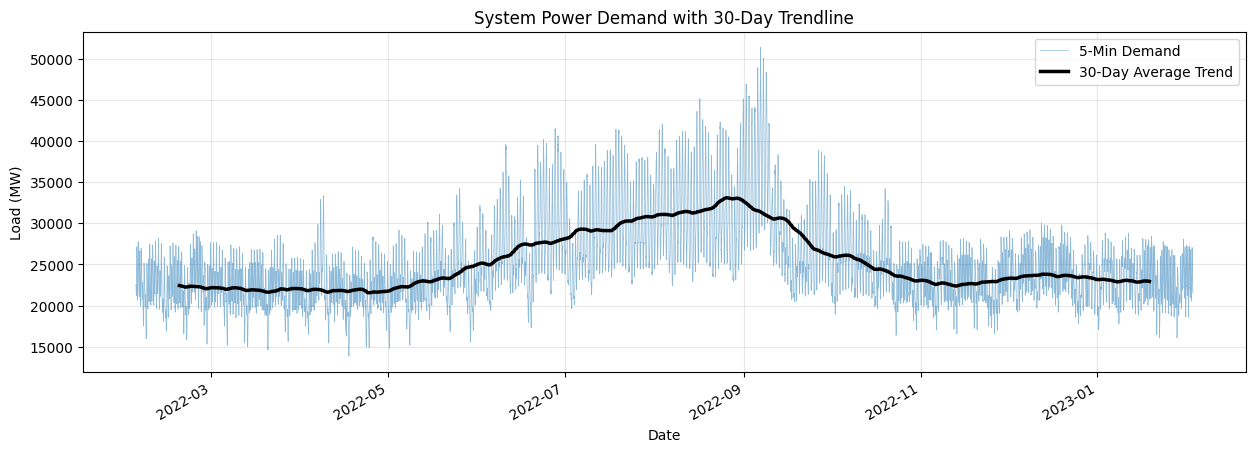

In [4]:
import matplotlib.pyplot as plt

# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()

In [5]:
## Scaling factor generation 
df = df.dropna()
median_load = np.median(df['load_mw'])
scaling_factor = df['load_mw'] / median_load
df['scaling_factor'] = scaling_factor

In [6]:
## Identify Generatoy limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 0.95
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()
current_peak = df['scaling_factor'].max()

if current_peak > max_scaling_factor:
    rescale_factor = max_scaling_factor / current_peak
    df['scaling_factor'] = df['scaling_factor'] * rescale_factor

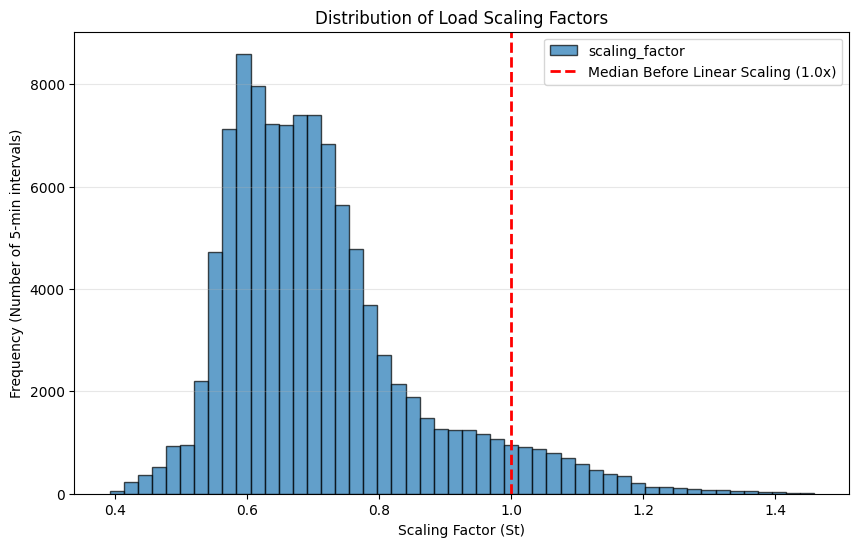

In [7]:
### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

In [8]:
## Scale IEEE 118 test bus today to follow the variance of our data

scaled_nodal_demand = pd.DataFrame(
    np.outer(df['scaling_factor'], nodal_demand['Pd_mw']),
    index=df.index,                 # Your 105,000 timestamps become the rows
    columns=nodal_demand['bus_id']  # Your 118 bus IDs become the columns
)


### 4. Demand Distribution and Sample for Scenarios (Dumb Method)

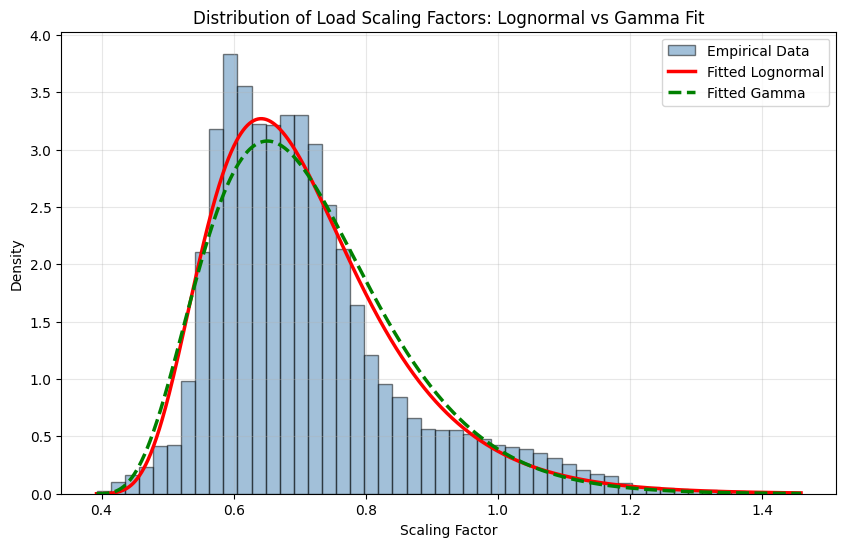

In [9]:
### Fit a distribution to the scaling factors
import scipy.stats as stats

# Assuming 'df' is your DataFrame and 'scaling_factor' is the column
# Drop any NaN values before fitting
data = df['scaling_factor'].dropna().values

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data)
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_gamma = stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma)

# --- 4. Plot the Results ---
plt.figure(figsize=(10, 6))

# Plot the empirical histogram (must set density=True to match PDF scale)
plt.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Empirical Data')

# Overlay the fitted PDFs
plt.plot(x, pdf_lognorm, 'r-', lw=2.5, label='Fitted Lognormal')
plt.plot(x, pdf_gamma, 'g--', lw=2.5, label='Fitted Gamma')

plt.title('Distribution of Load Scaling Factors: Lognormal vs Gamma Fit')
plt.xlabel('Scaling Factor')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Calculate the negative log-likelihood (NLL) for both fits
# NLL is what scipy actually minimizes during the fit
nll_lognorm = stats.lognorm.nnlf((shape_lognorm, loc_lognorm, scale_lognorm), data)
nll_gamma = stats.gamma.nnlf((shape_gamma, loc_gamma, scale_gamma), data)

# Number of parameters (k) is 3 for both distributions (shape, loc, scale)
k = 3
n = len(data)

# Calculate AIC: AIC = 2k - 2*ln(L)  (where -ln(L) is the NLL)
aic_lognorm = 2 * k + 2 * nll_lognorm
aic_gamma = 2 * k + 2 * nll_gamma

print(f"Lognormal AIC: {aic_lognorm:.2f}")
print(f"Gamma AIC: {aic_gamma:.2f}")

if aic_lognorm < aic_gamma:
    print("The Lognormal distribution provides a better fit.")
else:
    print("The Gamma distribution provides a better fit.")

Lognormal AIC: -129519.73
Gamma AIC: -126916.73
The Lognormal distribution provides a better fit.


In [11]:
### Generate the scenarios
num_samples = 100
scale_scenarios = stats.lognorm.rvs(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm, size=num_samples)
nodes_to_mult = nodal_demand['Pd_mw']
node_scenarios = np.outer(scale_scenarios, nodes_to_mult)

In [12]:
from scipy.stats import lognorm
scaling_factor_hat = lognorm.mean(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
Pn_d_hat = scaling_factor_hat * nodal_demand.set_index('bus_id')['Pd_mw']

### 5. Run Two Stage Optimization (First Methodology)

Prdict Demand, input into first stage, optimize, then use scenarios and optimize second stage, cost is sum. 

In [13]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — Formulation 1 (pyomo version)
# Stage 1: deterministic DC-OPF on point forecast Pn_d_hat -> Pg_star
# Stage 2: per-scenario recourse with load-shed / curtailment slacks
# =============================================================================
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# -----------------------------------------------------------------------------
# 1. Build index maps and system data
# -----------------------------------------------------------------------------
bus_ids   = nodal_demand['bus_id'].astype(int).values
N_BUS     = len(bus_ids)
bus_idx   = {int(b): i for i, b in enumerate(bus_ids)}

gen_bus     = gen_limits['bus_id'].astype(int).values
gen_bus_idx = np.array([bus_idx[int(b)] for b in gen_bus])
Pg_min      = gen_limits['Pmin_mw'].values
Pg_max      = gen_limits['Pmax_mw'].values
c1          = gen_costs['cost_linear'].values
c0          = gen_costs['cost_constant'].values
N_GEN       = len(gen_bus)

from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values
R_line   = branch_data['thermal_limit_mw'].values
N_LINE   = len(B_line)

SLACK  = 0
VOLL   = 10000.0
C_CURT = 1000.0

RAMP_UP_COST   = 50.0   # $/MWh, uniform across generators
RAMP_DOWN_COST = 10.0   # $/MWh, uniform

c_up   = np.full(N_GEN, RAMP_UP_COST)
c_down = np.full(N_GEN, RAMP_DOWN_COST)


# Align Pn_d_hat to bus order
if isinstance(Pn_d_hat, pd.Series):
    Pd_hat = np.array([Pn_d_hat[b] for b in bus_ids])
else:
    Pd_hat = np.asarray(Pn_d_hat)


node_scen = np.asarray(node_scenarios)
N_SCEN    = node_scen.shape[0]


In [14]:

# # -----------------------------------------------------------------------------
# # 2. Helper: build a DC-OPF pyomo model (reused for stage 1 and stage 2)
# # -----------------------------------------------------------------------------
# def build_dcopf(Pd, Pg_fixed=None, recourse_mode=False):
#     """
#     Build a DC-OPF model.
#     - Stage 1:  Pg_fixed=None, recourse_mode=False  -> dispatch Pg freely.
#     - Stage 2:  Pg_fixed=Pg_star, recourse_mode=True -> dispatch = Pg_star + dP_up - dP_dn,
#                 with load-shed/curtailment slacks at high penalty.
#     """
#     m = pyo.ConcreteModel()

#     m.G = pyo.RangeSet(0, N_GEN - 1)
#     m.N = pyo.RangeSet(0, N_BUS - 1)
#     m.E = pyo.RangeSet(0, N_LINE - 1)

#     m.theta = pyo.Var(m.N, domain=pyo.Reals, initialize=0.0)
#     m.Pe    = pyo.Var(m.E, domain=pyo.Reals, bounds=lambda m, e: (-R_line[e], R_line[e]))

#     if not recourse_mode:
#         # Stage 1: dispatch Pg within bounds
#         m.Pg = pyo.Var(m.G, domain=pyo.Reals, bounds=lambda m, g: (Pg_min[g], Pg_max[g]))
#     else:
#         # Stage 2: Pg = Pg_fixed + dP_up - dP_dn
#         m.dP_up = pyo.Var(m.G, domain=pyo.NonNegativeReals)
#         m.dP_dn = pyo.Var(m.G, domain=pyo.NonNegativeReals)
#         m.G_shed = pyo.Var(m.N, domain=pyo.NonNegativeReals, bounds=lambda m, n: (0, Pd[n]))
#         m.G_curt = pyo.Var(m.N, domain=pyo.NonNegativeReals)

#         # Derived Pg expression
#         def _Pg_expr(m, g):
#             return Pg_fixed[g] + m.dP_up[g] - m.dP_dn[g]
#         m.Pg = pyo.Expression(m.G, rule=_Pg_expr)

#         # Enforce physical generator limits on the actual dispatch
#         m.pg_lo = pyo.Constraint(m.G, rule=lambda m, g: m.Pg[g] >= Pg_min[g])
#         m.pg_hi = pyo.Constraint(m.G, rule=lambda m, g: m.Pg[g] <= Pg_max[g])

#     # Slack bus angle
#     m.slack_con = pyo.Constraint(expr=m.theta[SLACK] == 0)

#     # DC flow equation: Pe = B * (theta_from - theta_to)
#     def _flow_rule(m, e):
#         return m.Pe[e] == B_line[e] * (m.theta[from_idx[e]] - m.theta[to_idx[e]])
#     m.flow = pyo.Constraint(m.E, rule=_flow_rule)

#     # Power balance at each bus
#     # gen_at_bus - demand = net outflow on lines
#     # Precompute which generators and lines touch each bus
#     gens_at_bus    = {n: [g for g in range(N_GEN) if gen_bus_idx[g] == n] for n in range(N_BUS)}
#     lines_from_bus = {n: [e for e in range(N_LINE) if from_idx[e] == n] for n in range(N_BUS)}
#     lines_to_bus   = {n: [e for e in range(N_LINE) if to_idx[e]   == n] for n in range(N_BUS)}

#     def _balance_rule(m, n):
#         gen_inj  = sum(m.Pg[g] for g in gens_at_bus[n])
#         out_flow = sum(m.Pe[e] for e in lines_from_bus[n])
#         in_flow  = sum(m.Pe[e] for e in lines_to_bus[n])
#         net_outflow = out_flow - in_flow
#         if recourse_mode:
#             # Effective demand is Pd - G_shed; excess generation absorbed by G_curt
#             return gen_inj - (Pd[n] - m.G_shed[n]) - m.G_curt[n] == net_outflow
#         else:
#             return gen_inj - Pd[n] == net_outflow
#     m.balance = pyo.Constraint(m.N, rule=_balance_rule)

#     # Objective
#     if not recourse_mode:
#         m.obj = pyo.Objective(
#             expr=sum(c1[g] * m.Pg[g] for g in range(N_GEN)) + float(np.sum(c0)),
#             sense=pyo.minimize,
#         )
#     else:
#         m.obj = pyo.Objective(
#         expr=(
#             sum(c_up[g] * m.dP_up[g] + c_down[g] * m.dP_dn[g] for g in range(N_GEN))
#             + VOLL   * sum(m.G_shed[n] for n in range(N_BUS))
#             + C_CURT * sum(m.G_curt[n] for n in range(N_BUS))
#         ),
#         sense=pyo.minimize,
#     )
#     return m

# # -----------------------------------------------------------------------------
# # 3. STAGE 1: solve deterministic DC-OPF on forecast
# # -----------------------------------------------------------------------------
# solver = SolverFactory("appsi_highs")   # HiGHS via highspy
# m1 = build_dcopf(Pd_hat, recourse_mode=False)
# res1 = solver.solve(m1)
# assert (res1.solver.termination_condition.name == "optimal"), \
#     f"Stage 1 not optimal: {res1.solver.termination_condition}"

# Pg_star = np.array([pyo.value(m1.Pg[g]) for g in range(N_GEN)])
# cost_s1 = pyo.value(m1.obj)
# print(f"Stage 1 cost: ${cost_s1:,.2f}/hr   (sum Pg={Pg_star.sum():.1f} MW, "
#       f"sum Pd_hat={Pd_hat.sum():.1f} MW)")

# # -----------------------------------------------------------------------------
# # 4. STAGE 2: solve per-scenario recourse
# # -----------------------------------------------------------------------------
# node_scen = np.asarray(node_scenarios)
# N_SCEN    = node_scen.shape[0]

# stage2_costs = np.zeros(N_SCEN)
# shed_mwh     = np.zeros(N_SCEN)
# curt_mwh     = np.zeros(N_SCEN)
# dP_up_mwh    = np.zeros(N_SCEN)
# dP_dn_mwh    = np.zeros(N_SCEN)
# infeasible   = []

# for s in range(N_SCEN):
#     m2 = build_dcopf(node_scen[s, :], Pg_fixed=Pg_star, recourse_mode=True)
#     res2 = solver.solve(m2)
#     if res2.solver.termination_condition.name != "optimal":
#         infeasible.append(s)
#         stage2_costs[s] = np.nan
#         continue
#     stage2_costs[s] = pyo.value(m2.obj)
#     shed_mwh[s]     = sum(pyo.value(m2.G_shed[n]) for n in range(N_BUS))
#     curt_mwh[s]     = sum(pyo.value(m2.G_curt[n]) for n in range(N_BUS))
#     dP_up_mwh[s]    = sum(pyo.value(m2.dP_up[g]) for g in range(N_GEN))
#     dP_dn_mwh[s]    = sum(pyo.value(m2.dP_dn[g]) for g in range(N_GEN))

# # -----------------------------------------------------------------------------
# # 5. Report
# # -----------------------------------------------------------------------------
# valid = ~np.isnan(stage2_costs)
# exp_stage2 = float(np.mean(stage2_costs[valid]))
# total_cost = cost_s1 + exp_stage2

# print("\n" + "="*60)
# print("Two-Stage Stochastic DC-OPF — Formulation 1 Results")
# print("="*60)
# print(f"Stage 1 cost  (deterministic on forecast):  ${cost_s1:>14,.2f}/hr")
# print(f"E[Stage 2 cost] (avg across scenarios):     ${exp_stage2:>14,.2f}/hr")
# print(f"TOTAL expected cost:                        ${total_cost:>14,.2f}/hr")
# print(f"Scenarios solved:  {int(valid.sum())}/{N_SCEN}  (infeasible: {len(infeasible)})")
# print(f"Avg load shed:     {shed_mwh[valid].mean():>8,.2f} MW   "
#       f"(max: {shed_mwh[valid].max():.2f})")
# print(f"Avg curtailment:   {curt_mwh[valid].mean():>8,.2f} MW   "
#       f"(max: {curt_mwh[valid].max():.2f})")
# print(f"Avg up-ramp:       {dP_up_mwh[valid].mean():>8,.2f} MW")
# print(f"Avg down-ramp:     {dP_dn_mwh[valid].mean():>8,.2f} MW")

# results_formulation1 = {
#     "Pg_star":      Pg_star,
#     "cost_s1":      cost_s1,
#     "stage2_costs": stage2_costs,
#     "exp_stage2":   exp_stage2,
#     "total_cost":   total_cost,
#     "shed_mwh":     shed_mwh,
#     "curt_mwh":     curt_mwh,
#     "dP_up_mwh":    dP_up_mwh,
#     "dP_dn_mwh":    dP_dn_mwh,
#     "infeasible":   infeasible,
# }

### 6. Run Two Stage Optimization (Second Methodology)

Predict demand, use this to create scenarios, and then optimize with recourse decision. 

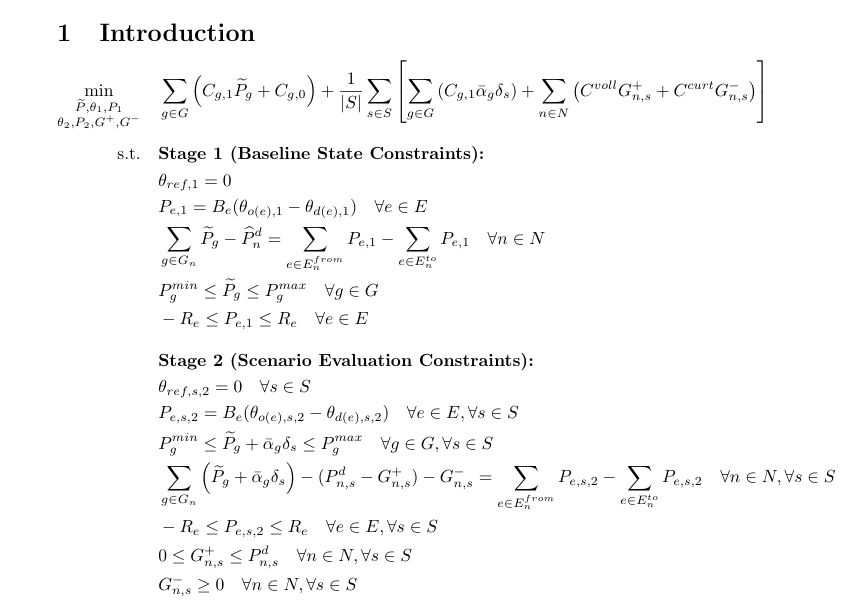

In [15]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — Formulation 2 with AFFINE RECOURSE (Gurobi)
# =============================================================================
# Stage 1: choose (Pg, alpha) knowing the scenario distribution.
# Stage 2: automatic affine response Pg_s = Pg + alpha * delta_s.
# Delta_s is precomputed from raw demand shifts (exact in lossless DC-OPF).
# =============================================================================
import numpy as np
import gurobipy as gp
from gurobipy import GRB

def build_and_solve_affine(Pd_hat, node_scen, voll=VOLL, c_curt=C_CURT, verbose=True):
    N_SCEN = node_scen.shape[0]

    # Precomputed scenario-wide imbalance
    delta = node_scen.sum(axis=1) - Pd_hat.sum()   # shape (N_SCEN,)

    # Incidence lookups
    gens_at_bus    = [[g for g in range(N_GEN) if gen_bus_idx[g] == n] for n in range(N_BUS)]
    lines_from_bus = [[e for e in range(N_LINE) if from_idx[e] == n] for n in range(N_BUS)]
    lines_to_bus   = [[e for e in range(N_LINE) if to_idx[e]   == n] for n in range(N_BUS)]

    # --- Model ---
    m = gp.Model("stochastic_dcopf_affine")
    m.Params.OutputFlag = 1 if verbose else 0

    # --- Stage 1 variables ---
    Pg     = m.addMVar(N_GEN, lb=Pg_min, ub=Pg_max, name="Pg")
    theta1 = m.addMVar(N_BUS, lb=-GRB.INFINITY, name="theta1")
    Pe1    = m.addMVar(N_LINE, lb=-R_line, ub=R_line, name="Pe1")

    # --- Stage 2 variables (per scenario) ---
    G_shed = m.addMVar((N_SCEN, N_BUS), lb=0.0, ub=node_scen, name="G_shed")
    G_curt = m.addMVar((N_SCEN, N_BUS), lb=0.0, name="G_curt")
    theta2 = m.addMVar((N_SCEN, N_BUS), lb=-GRB.INFINITY, name="theta2")
    Pe2    = m.addMVar((N_SCEN, N_LINE),
                       lb=np.tile(-R_line, (N_SCEN, 1)),
                       ub=np.tile( R_line, (N_SCEN, 1)), name="Pe2")

    # --- Stage 1 constraints ---
    m.addConstr(theta1[SLACK] == 0, name="slack1")

    for e in range(N_LINE):
        m.addConstr(Pe1[e] == B_line[e] * (theta1[from_idx[e]] - theta1[to_idx[e]]),
                    name=f"flow1_{e}")

    for n in range(N_BUS):
        gen_sum = gp.quicksum(Pg[g] for g in gens_at_bus[n])
        out_sum = gp.quicksum(Pe1[e] for e in lines_from_bus[n])
        in_sum  = gp.quicksum(Pe1[e] for e in lines_to_bus[n])
        m.addConstr(gen_sum - Pd_hat[n] == out_sum - in_sum, name=f"balance1_{n}")

# --- Stage 2 constraints ---
    
    # Convert the dataframe column to a fixed numpy array
    alpha_fixed = gen_limits['alpha_fixed'].values

    for s in range(N_SCEN):
        m.addConstr(theta2[s, SLACK] == 0, name=f"slack2_{s}")

        for e in range(N_LINE):
            m.addConstr(
                Pe2[s, e] == B_line[e] * (theta2[s, from_idx[e]] - theta2[s, to_idx[e]]),
                name=f"flow2_{s}_{e}",
            )

        # Pg_s = Pg + alpha_fixed * delta_s  (linear since delta_s is a constant)
        for g in range(N_GEN):
            Pg_s = Pg[g] + alpha_fixed[g] * delta[s]
            m.addConstr(Pg_s >= Pg_min[g], name=f"pg_lo_{s}_{g}")
            m.addConstr(Pg_s <= Pg_max[g], name=f"pg_hi_{s}_{g}")

        for n in range(N_BUS):
            # Replace alpha[g] with alpha_fixed[g] here
            gen_inj = gp.quicksum(Pg[g] + alpha_fixed[g] * delta[s] for g in gens_at_bus[n])
            out_sum = gp.quicksum(Pe2[s, e] for e in lines_from_bus[n])
            in_sum  = gp.quicksum(Pe2[s, e] for e in lines_to_bus[n])
            eff_dem = node_scen[s, n] - G_shed[s, n]
            m.addConstr(gen_inj - eff_dem - G_curt[s, n] == out_sum - in_sum,
                        name=f"balance2_{s}_{n}")

    # --- Objective ---
    stage1_cost = gp.quicksum(c1[g] * Pg[g] for g in range(N_GEN)) + float(np.sum(c0))

    stage2_cost_terms = []
    for s in range(N_SCEN):
        # Replace alpha[g] with alpha_fixed[g] here
        dispatch_cost = gp.quicksum(c1[g] * alpha_fixed[g] * delta[s] for g in range(N_GEN))
        shed_cost     = voll   * gp.quicksum(G_shed[s, n] for n in range(N_BUS))
        curt_cost     = c_curt * gp.quicksum(G_curt[s, n] for n in range(N_BUS))
        stage2_cost_terms.append(dispatch_cost + shed_cost + curt_cost)

    expected_stage2 = gp.quicksum(stage2_cost_terms) / N_SCEN
    m.setObjective(stage1_cost + expected_stage2, GRB.MINIMIZE)

    # --- Solve ---
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Gurobi did not solve to optimality. Status={m.Status}")

    # --- Extract ---
    Pg_val    = Pg.X
    shed_val  = G_shed.X   # shape (N_SCEN, N_BUS)
    curt_val  = G_curt.X

    return {
        "Pg":          Pg_val,
        "alpha":       alpha_fixed,  # Return the fixed array instead of alpha.X
        "delta":       delta,
        "shed":        shed_val,
        "curt":        curt_val,
        "total_cost":  m.ObjVal,
        "stage1_cost": float(c1 @ Pg_val + np.sum(c0)),
    }

# =============================================================================
# Run
# =============================================================================
print("Building and solving affine-recourse stochastic program in Gurobi...")
res = build_and_solve_affine(Pd_hat, node_scen)

Pg_f2       = res["Pg"]
alpha_f2    = res["alpha"]
delta_vec   = res["delta"]
shed_mat    = res["shed"]
curt_mat    = res["curt"]
cost_f2     = res["total_cost"]
stage1_cost_f2 = res["stage1_cost"]

# Per-scenario breakdown
shed_f2        = shed_mat.sum(axis=1)
curt_f2        = curt_mat.sum(axis=1)
dispatch_costs = (c1 * alpha_f2) @ np.ones((N_GEN, 1)) * delta_vec[:, None]  # not used, just illustrative
stage2_costs_f2 = np.array([
    float(np.sum(c1 * alpha_f2) * delta_vec[s])
    + VOLL * shed_f2[s] + C_CURT * curt_f2[s]
    for s in range(len(delta_vec))
])
exp_stage2_f2 = stage2_costs_f2.mean()

# --- Report ---
print("\n" + "=" * 60)
print("Formulation 2 with Affine Recourse (Gurobi) — Results")
print("=" * 60)
print(f"Stage 1 cost:                       ${stage1_cost_f2:>14,.2f}/hr")
print(f"E[Stage 2 cost]:                    ${exp_stage2_f2:>14,.2f}/hr")
print(f"TOTAL expected cost:                ${cost_f2:>14,.2f}/hr")
print(f"Sum alpha:                          {alpha_f2.sum():.6f}")
print(f"Non-zero participation factors:     {(alpha_f2 > 1e-6).sum()}/{N_GEN}")
print(f"Max participation factor:           {alpha_f2.max():.4f}")
print(f"Avg |system response| per scenario: {np.abs(delta_vec).mean():.1f} MW")
print(f"Avg load shed:                      {shed_f2.mean():.2f} MW")
print(f"Avg curtailment:                    {curt_f2.mean():.2f} MW")

print("\nTop 5 generators by participation factor:")
top = np.argsort(alpha_f2)[-5:][::-1]
for g in top:
    print(f"  Gen {g:3d}:  alpha = {alpha_f2[g]:.4f},  "
          f"Pg = {Pg_f2[g]:6.1f} MW,  Pmax = {Pg_max[g]:6.1f} MW,  "
          f"headroom = {Pg_max[g] - Pg_f2[g]:6.1f} MW,  c1 = ${c1[g]:.2f}")

results_formulation2_affine = {
    "Pg":            Pg_f2,
    "alpha":         alpha_f2,
    "delta":         delta_vec,
    "stage1_cost":   stage1_cost_f2,
    "stage2_costs":  stage2_costs_f2,
    "exp_stage2":    exp_stage2_f2,
    "total_cost":    cost_f2,
    "shed":          shed_f2,
    "curt":          curt_f2,
}

Building and solving affine-recourse stochastic program in Gurobi...
Set parameter Username
Set parameter LicenseID to value 2711111
Academic license - for non-commercial use only - expires 2026-09-20
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 41605 rows, 54358 columns and 133885 nonzeros
Model fingerprint: 0x9abb349b
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 1e+02]
  Bounds range     [1e+00, 7e+03]
  RHS range        [2e-02, 1e+03]
Presolve removed 24109 rows and 15344 columns
Presolve time: 0.18s
Presolved: 17496 rows, 39014 columns, 91933 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 Dense 

# Phase 2: Predict than Optimizes (Dumb)

### 2.1: Predict Demand baesd on time, temperature, and humidity

### Actually predict demand based on temperature and time of day, year.

In [16]:
import sys, numpy, scipy, statsmodels, pandas
print("Python:", sys.executable)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("pandas:", pandas.__version__)

Python: c:\Users\anble\anaconda3\envs\loadfc\python.exe
numpy: 2.4.4
scipy: 1.17.1
statsmodels: 0.14.6
pandas: 2.3.3


In [17]:
# Block 2: MAFS + ISTD + PGBM pipeline (Sections 3–7 of the paper)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import STL
import warnings; warnings.filterwarnings("ignore")

df.index = pd.DatetimeIndex(df.index).as_unit("us")

if "temperature_raw" not in df.columns:
    df["temperature_raw"] = df["temperature"]

df["month"]        = df.index.month
df["week"]         = df.index.isocalendar().week.astype(int)
df["day_of_month"] = df.index.day
df["day_of_week"]  = df.index.dayofweek
df["hour"]         = df.index.hour + df.index.minute / 60.0

try:
    import holidays as _holidays
    _us = _holidays.US(years=list(range(df.index.year.min(), df.index.year.max() + 1)))
    df["is_holiday"] = [1 if d.date() in _us else 0 for d in df.index]
    print(f"Holiday feature added — {df['is_holiday'].sum()} holiday intervals")
except ImportError:
    df["is_holiday"] = 0
    print("'holidays' package not found — run: pip install holidays")

# =========================================================
# 3. MAFS — Multi-Approach Feature Selection
# =========================================================
candidate_features = ["temperature_raw", "humidity", "month", "day_of_month",
                      "week", "day_of_week", "hour", "is_holiday"]
target = "load_mw"

corr = df[candidate_features + [target]].corr()[target].drop(target)
print("Pearson correlation with load:\n", corr.round(3))

rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(df[candidate_features], df[target])
importance = pd.Series(rf.feature_importances_, index=candidate_features).sort_values(ascending=False)
print("\nRandom Forest feature importance:\n", importance.round(4))

selected = ["temp_stationary", "week", "hour", "day_of_month", "day_of_week", "is_holiday"]

# =========================================================
# 4. KPSS stationarity test
# =========================================================
def kpss_check(series, name):
    clean = series.replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) < 20:
        print(f"{name:12s} — insufficient data ({len(clean)} obs), skipping"); return
    stat, p, _, crit = kpss(clean, regression="c", nlags="auto")
    print(f"{name:12s} KPSS stat={stat:.4f}  p={p:.4f}  "
          f"{'STATIONARY' if stat < crit['5%'] else 'NON-STATIONARY'}")

print("\nBefore ISTD:")
kpss_check(df["load_mw"],         "load_mw")
kpss_check(df["temperature_raw"], "temperature")

# =========================================================
# 5. ISTD helpers
# =========================================================
def istd(series, periods, stl_kwargs=None):
    stl_kwargs = stl_kwargs or {}
    idx = series.index
    resid_vals = series.to_numpy().astype(float)
    seasonals = {}
    for p in periods:
        stl = STL(pd.Series(resid_vals, index=idx), period=p, robust=True, **stl_kwargs).fit()
        s = np.asarray(stl.seasonal, dtype=float)
        seasonals[p] = pd.Series(s, index=idx)
        resid_vals = resid_vals - s
    final = STL(pd.Series(resid_vals, index=idx), period=periods[0], robust=True).fit()
    trend_vals = np.asarray(final.trend, dtype=float)
    return pd.Series(trend_vals, index=idx), seasonals, pd.Series(resid_vals - trend_vals, index=idx)

def upsample(sub_series, target_index):
    h = sub_series.index.as_unit("us").asi8.astype(float)
    t = pd.DatetimeIndex(target_index).as_unit("us").asi8.astype(float)
    return pd.Series(np.interp(t, h, sub_series.to_numpy().astype(float)), index=target_index)

def project_seasonal(train_seasonal_5min, test_index, period_5min):
    """
    Group training seasonal values by their actual clock key (no offset arithmetic),
    average each key across all training cycles, then look up test timestamps.
    Phase is always correct because we use real timestamps, not position indices.
    """
    tidx = pd.DatetimeIndex(train_seasonal_5min.index)
    if period_5min == 288:
        keys_tr = (tidx.hour * 12 + tidx.minute // 5).values
    elif period_5min == 2016:
        keys_tr = (tidx.dayofweek * 288 + tidx.hour * 12 + tidx.minute // 5).values
    else:
        t0_us = tidx.as_unit("us").asi8[0]
        keys_tr = ((tidx.as_unit("us").asi8 - t0_us) // (300 * 1_000_000)).astype(int) % period_5min

    profile = pd.Series(train_seasonal_5min.values, index=keys_tr).groupby(level=0).mean()

    teidx = pd.DatetimeIndex(test_index)
    if period_5min == 288:
        keys_te = (teidx.hour * 12 + teidx.minute // 5).values
    elif period_5min == 2016:
        keys_te = (teidx.dayofweek * 288 + teidx.hour * 12 + teidx.minute // 5).values
    else:
        keys_te = ((teidx.as_unit("us").asi8 - t0_us) // (300 * 1_000_000)).astype(int) % period_5min

    return pd.Series(profile.reindex(keys_te).values, index=test_index)

# =========================================================
# 6. Honest train/test split BEFORE any decomposition
#    80% train | 20% test — time-ordered, no shuffling
# =========================================================
SPLIT_FRAC = 0.8
split_loc  = int(SPLIT_FRAC * len(df))
df_train   = df.iloc[:split_loc]
df_test    = df.iloc[split_loc:]
print(f"\nTrain: {df_train.index[0].date()} → {df_train.index[-1].date()}  ({len(df_train):,} rows)")
print(f"Test:  {df_test.index[0].date()}  → {df_test.index[-1].date()}   ({len(df_test):,} rows)")

# =========================================================
# 7. ISTD fitted on TRAINING data only
# =========================================================
df_sub_tr = df_train[["load_mw", "temperature_raw"]].resample("15min").mean()
df_sub_tr = df_sub_tr.interpolate(method="time").bfill().ffill()

print("\nRunning ISTD on training data only (~8-10 min)...")
load_trend_tr, load_seasons_tr, load_resid_tr = istd(df_sub_tr["load_mw"],         periods=[96, 672])
temp_trend_tr, temp_seasons_tr, temp_resid_tr = istd(df_sub_tr["temperature_raw"], periods=[96])
print(f"ISTD done — NaN check: load={load_resid_tr.isna().sum()}, temp={temp_resid_tr.isna().sum()}")

# Upsample training components back to 5-min
load_trend_5m_tr   = upsample(load_trend_tr,   df_train.index)
temp_trend_5m_tr   = upsample(temp_trend_tr,   df_train.index)
load_seasons_5m_tr = {p: upsample(s, df_train.index) for p, s in load_seasons_tr.items()}
temp_seasons_5m_tr = {p: upsample(s, df_train.index) for p, s in temp_seasons_tr.items()}
load_resid_5m_tr   = upsample(load_resid_tr,   df_train.index)
temp_resid_5m_tr   = upsample(temp_resid_tr,   df_train.index)

# Scalers fit on training residuals only
load_scaler = StandardScaler().fit(load_resid_5m_tr.values.reshape(-1, 1))
temp_scaler = StandardScaler().fit(temp_resid_5m_tr.values.reshape(-1, 1))

df.loc[df_train.index, "load_stationary"] = load_scaler.transform(
    load_resid_5m_tr.values.reshape(-1, 1)).ravel()
df.loc[df_train.index, "temp_stationary"] = temp_scaler.transform(
    temp_resid_5m_tr.values.reshape(-1, 1)).ravel()

# =========================================================
# Project seasonal + trend into test period (no test data used)
# =========================================================
# Trend: extend using the last training trend value (flat extrapolation)
last_trend_load = float(load_trend_5m_tr.iloc[-1])
last_trend_temp = float(temp_trend_5m_tr.iloc[-1])
load_trend_5m_te = pd.Series(last_trend_load, index=df_test.index)
temp_trend_5m_te = pd.Series(last_trend_temp, index=df_test.index)

# Seasonal: wrap on period (5-min periods: daily=288, weekly=2016)
PERIOD_MAP = {96: 288, 672: 2016}   # 15-min period → 5-min period
load_seasons_5m_te = {p: project_seasonal(load_seasons_5m_tr[p], df_test.index, PERIOD_MAP[p])
                      for p in load_seasons_tr}
temp_seasons_5m_te = {p: project_seasonal(temp_seasons_5m_tr[p], df_test.index, PERIOD_MAP[p])
                      for p in temp_seasons_tr}

# Residuals for test = actual - projected trend - projected seasonals
load_resid_5m_te = df_test["load_mw"].copy()
load_resid_5m_te -= load_trend_5m_te
for s in load_seasons_5m_te.values():
    load_resid_5m_te -= s

temp_resid_5m_te = df_test["temperature_raw"].copy()
temp_resid_5m_te -= temp_trend_5m_te
for s in temp_seasons_5m_te.values():
    temp_resid_5m_te -= s

df.loc[df_test.index, "load_stationary"] = load_scaler.transform(
    load_resid_5m_te.values.reshape(-1, 1)).ravel()
df.loc[df_test.index, "temp_stationary"] = temp_scaler.transform(
    temp_resid_5m_te.values.reshape(-1, 1)).ravel()

print("\nAfter ISTD:")
kpss_check(df.loc[df_train.index, "load_stationary"], "load_stat_tr")
kpss_check(df.loc[df_test.index,  "load_stationary"], "load_stat_te")



# =========================================================
# 8. PGBM — Set Up Training Pipeline
# =========================================================
N_LAGS = 6
for k in range(1, N_LAGS + 1):
    df[f"lag_{k}"] = df["load_stationary"].shift(k)

feature_cols = selected + [f"lag_{k}" for k in range(1, N_LAGS + 1)]

train_data = df.loc[df_train.index].dropna().copy()
test_data  = df.loc[df_test.index ].dropna().copy()

X_tr, y_tr = train_data[feature_cols].values, train_data["load_stationary"].values
X_te, y_te = test_data[feature_cols].values,  test_data["load_stationary"].values
idx_te     = test_data.index

# =========================================================
# Recursive multi-step prediction: replace oracle lags with own predictions
# X_te columns: [non-lag features..., lag_1, lag_2, ..., lag_N_LAGS]
# =========================================================
lag_start = len(selected)   # index of lag_1 in feature vector

def predict_rolling_dayahead(model, X_te, lag_start, n_lags, horizon=288):
    """
    Rolling day-ahead forecast: predict `horizon` steps using recursive lags,
    then reset to actual observed lags at each horizon boundary.
    Simulates real operations — you get new meter readings each morning and
    issue a fresh 24-h forecast. No multi-day lag drift.
    """
    X = X_te.copy()
    preds = np.empty(len(X))
    for start in range(0, len(X), horizon):
        end = min(start + horizon, len(X))
        for t in range(start, end):
            preds[t] = model.predict(X[t:t+1])[0]
            for k in range(1, n_lags + 1):
                future = t + k
                if future < end:          # only overwrite within this horizon
                    X[future, lag_start + k - 1] = preds[t]
        # Beyond `end`, X still holds actual lag values from X_te,
        # so the next window starts with real observed lags — no drift.
    return preds

'holidays' package not found — run: pip install holidays
Pearson correlation with load:
 temperature_raw    0.476
humidity           0.531
month              0.223
day_of_month      -0.037
week               0.213
day_of_week       -0.171
hour               0.407
is_holiday           NaN
Name: load_mw, dtype: float64

Random Forest feature importance:
 humidity           0.3795
hour               0.3399
week               0.1041
temperature_raw    0.0683
day_of_week        0.0541
day_of_month       0.0290
month              0.0251
is_holiday         0.0000
dtype: float64

Before ISTD:
load_mw      KPSS stat=8.1134  p=0.0100  NON-STATIONARY
temperature  KPSS stat=9.1465  p=0.0100  NON-STATIONARY

Train: 2022-02-03 → 2022-11-22  (84,050 rows)
Test:  2022-11-22  → 2023-02-02   (21,013 rows)

Running ISTD on training data only (~8-10 min)...
ISTD done — NaN check: load=0, temp=0

After ISTD:
load_stat_tr KPSS stat=0.0728  p=0.1000  STATIONARY
load_stat_te KPSS stat=0.9860  p=0.0100  NON-ST

In [18]:
# # =========================================================
# # 8. Plot multi-day forecast with 95% CI
# # =========================================================
# N_DAYS    = 5    # number of days to plot
# START_DAY = 10    # 0 = first test day; change to e.g. 30, 60, 90 to skip ahead
# intervals_per_day = 288   # 5-min × 288 = 24 h

# offset = START_DAY * intervals_per_day

# fig, axes = plt.subplots(N_DAYS, 1, figsize=(13, 3 * N_DAYS), sharex=False)
# if N_DAYS == 1:
#     axes = [axes]

# for i, ax in enumerate(axes):
#     day_idx = idx_te[offset + i * intervals_per_day : offset + (i + 1) * intervals_per_day]
#     ax.plot(day_idx, actual.loc[day_idx],   color="crimson", linewidth=1.2, label="Actual")
#     ax.plot(day_idx, pred_mw.loc[day_idx],  color="navy",    linewidth=1.2, label="Predicted")
#     ax.fill_between(day_idx,
#                     lower_mw.loc[day_idx],
#                     upper_mw.loc[day_idx],
#                     alpha=0.2, color="navy", label="95% CI")
#     ax.set_title(day_idx[0].strftime("%A, %b %-d %Y"), fontsize=10)
#     ax.set_ylabel("Load (MW)")
#     ax.grid(True, alpha=0.3)
#     if i == 0:
#         ax.legend(loc="upper right", fontsize=8)

# fig.suptitle(f"PGBM {N_DAYS}-Day Forecast with 95% Confidence Interval", fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()


### 2.2 Run model from phase one but on predicted demand

### 2.2.1 Train 17 Quantil PGBM with train/load

In [19]:
# =============================================================================
# PGBM at 17 quantile levels 
# Saves models to disk so retraining isn't needed if you restart the kernel.
# =============================================================================
import os
import pickle
from sklearn.ensemble import GradientBoostingRegressor

QUANTILE_LEVELS = [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40,
                   0.50,
                   0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.975, 0.99]

MODELS_PATH = "pgbm_models_17q.pkl"

gbr_params = dict(
    n_estimators=120, max_depth=4, learning_rate=0.1,
    min_samples_leaf=20, min_samples_split=3,
    loss="quantile", random_state=0,
)

def train_all_quantiles(X_tr, y_tr, quantile_levels, params):
    models = {}
    for i, alpha in enumerate(quantile_levels):
        print(f"  [{i+1:2d}/{len(quantile_levels)}]  training alpha={alpha:.3f}...", flush=True)
        m = GradientBoostingRegressor(alpha=alpha, **params)
        m.fit(X_tr, y_tr)
        models[alpha] = m
    return models

# --- Load if available, else train and save ---
if os.path.exists(MODELS_PATH):
    print(f"Loading trained models from {MODELS_PATH} ...")
    with open(MODELS_PATH, "rb") as f:
        models = pickle.load(f)
    print(f"Loaded {len(models)} quantile models.")
else:
    print(f"No cached models found. Training {len(QUANTILE_LEVELS)} quantile models...")
    print("(expect ~85 minutes total)")
    import time; t0 = time.time()
    models = train_all_quantiles(X_tr, y_tr, QUANTILE_LEVELS, gbr_params)
    print(f"Trained in {(time.time()-t0)/60:.1f} minutes.")
    with open(MODELS_PATH, "wb") as f:
        pickle.dump(models, f)
    print(f"Saved to {MODELS_PATH}")

# --- Predict all quantile levels on the test set once ---
# Shape: (N_test, N_quantiles). Each row = CDF evaluated at QUANTILE_LEVELS.
# Uses the same recursive rolling fday-ahead forecast you already have.
print("\nPredicting all quantiles on test set (rolling day-ahead)...")
pgbm_quantile_preds_stat = np.column_stack([
    predict_rolling_dayahead(models[a], X_te, lag_start, N_LAGS)
    for a in QUANTILE_LEVELS
])
print(f"pgbm_quantile_preds_stat shape: {pgbm_quantile_preds_stat.shape}")

# --- Enforce monotonicity (fix quantile crossing) ---
# Independently-trained quantile regressors can produce non-monotone predictions;
# sort each row so the implied CDF is valid.
pgbm_quantile_preds_stat = np.sort(pgbm_quantile_preds_stat, axis=1)

# --- Sanity check: median should match your old pred_med ---
median_idx = QUANTILE_LEVELS.index(0.5)
median_stat = pgbm_quantile_preds_stat[:, median_idx]
print(f"Median prediction (stationary space): mean={median_stat.mean():.3f}, std={median_stat.std():.3f}")

Loading trained models from pgbm_models_17q.pkl ...
Loaded 17 quantile models.

Predicting all quantiles on test set (rolling day-ahead)...
pgbm_quantile_preds_stat shape: (21013, 17)
Median prediction (stationary space): mean=0.108, std=0.795


### 2.2.2 Generate Scenarios

In [20]:
# =============================================================================
# PGBM scenario generation — drop-in replacement for lognorm sampling
# =============================================================================
# Given a test-set position t (integer index into idx_te):
#   1. Look up the 17 quantile predictions (stationary space)
#   2. Reconstruct each quantile to CAISO MW via projected trend + seasonals
#   3. Build monotone CDF interpolator from (quantile_levels, MW values)
#   4. Sample N uniform draws, invert to get N MW samples
#   5. Convert each sample to IEEE-118 nodal MW via /median_load × nodal_base
# =============================================================================
from scipy.interpolate import PchipInterpolator

# --- One-time: compute training-only median_load for scaling conversion ---
# This must match how you set up the dumb baseline's scaling conversion.
# Use training data only to prevent test-period information leak.
MEDIAN_LOAD_TRAIN = float(df_train['load_mw'].median())
NODAL_BASE_MW     = nodal_demand.set_index('bus_id')['Pd_mw'].values  # (N_BUS,)
print(f"Using median_load (train-only): {MEDIAN_LOAD_TRAIN:.1f} MW")

# --- Precompute per-timestep MW-space quantile values (one-time, vectorized) ---
# For each test position t and each quantile level q, reconstruct from stationary
# space back to MW by:  inverse-scale, + trend(t), + sum of seasonals(t).
# All components are already aligned to idx_te from your existing code.
print("Reconstructing all quantile predictions to MW-space (one-time)...")

# trend + seasonals at each test timestamp, shape (N_test,)
mw_offset_per_t = (
    load_trend_5m_te.reindex(idx_te).values
    + sum(s.reindex(idx_te).values for s in load_seasons_5m_te.values())
)

# Inverse-standardize: stationary → residual MW
# load_scaler was fit as StandardScaler on training residuals,
# so inverse_transform(x) = x * scale + mean
resid_mw_all = load_scaler.inverse_transform(
    pgbm_quantile_preds_stat.reshape(-1, 1)
).reshape(pgbm_quantile_preds_stat.shape)

# Add back trend + seasonals → CAISO MW, shape (N_test, 17)
pgbm_quantile_preds_mw = resid_mw_all + mw_offset_per_t[:, None]

# Enforce monotonicity one more time after the reconstruction
# (Gaussian noise at tails could in principle break it; sorting is a no-op if monotone)
pgbm_quantile_preds_mw = np.sort(pgbm_quantile_preds_mw, axis=1)

print(f"pgbm_quantile_preds_mw shape: {pgbm_quantile_preds_mw.shape}")
print(f"Median forecast range: {pgbm_quantile_preds_mw[:, median_idx].min():.0f} – "
      f"{pgbm_quantile_preds_mw[:, median_idx].max():.0f} MW")

# --- The main sampling function ---
def sample_pgbm_scenarios(t_pos, n_scenarios=100, rng=None):
    """
    Draw `n_scenarios` nodal demand scenarios from PGBM's predictive distribution
    at test position `t_pos` (integer index into idx_te / pgbm_quantile_preds_mw).

    Returns: (n_scenarios, N_BUS) array of nodal demand in IEEE-118 MW scale.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Quantile values in CAISO MW at this timestep
    q_values_mw = pgbm_quantile_preds_mw[t_pos]   # shape (17,)
    q_levels    = np.array(QUANTILE_LEVELS)       # shape (17,)

    # Guard against any residual non-monotonicity (PchipInterpolator requires strictly increasing y)
    q_values_mw_sorted = np.maximum.accumulate(q_values_mw)

    # Build monotone interpolator: u in [0,1] → MW
    # PchipInterpolator gives smooth, monotone cubic interpolation
    cdf_inverse = PchipInterpolator(q_levels, q_values_mw_sorted, extrapolate=False)

    # Sample uniforms and invert. Clip to [0.01, 0.99] so we never extrapolate
    # beyond the quantile levels we actually trained.
    u = rng.uniform(q_levels[0], q_levels[-1], size=n_scenarios)
    caiso_mw_samples = cdf_inverse(u)                       # shape (n_scenarios,)

    # Convert to IEEE-118 nodal MW via the same scaling pipeline as dumb baseline
    scaling_factors = caiso_mw_samples / MEDIAN_LOAD_TRAIN  # dimensionless
    nodal_scenarios = np.outer(scaling_factors, NODAL_BASE_MW)  # (n_scen, N_BUS)

    return nodal_scenarios

def pgbm_forecast_at(t_pos):
    """Return the median (point forecast) at test position t_pos as IEEE nodal MW."""
    median_caiso_mw = pgbm_quantile_preds_mw[t_pos, median_idx]
    return (median_caiso_mw / MEDIAN_LOAD_TRAIN) * NODAL_BASE_MW

def pgbm_actual_at(t_pos):
    """The realized demand at test position t_pos, in IEEE nodal MW."""
    actual_caiso_mw = float(df.loc[idx_te[t_pos], "load_mw"])
    return (actual_caiso_mw / MEDIAN_LOAD_TRAIN) * NODAL_BASE_MW

# --- Smoke test ---
rng_test = np.random.default_rng(0)
test_scens = sample_pgbm_scenarios(t_pos=100, n_scenarios=100, rng=rng_test)
print(f"\nSmoke test at t_pos=100:")
print(f"  Scenarios shape: {test_scens.shape}")
print(f"  System totals — mean: {test_scens.sum(axis=1).mean():.1f} MW,  "
      f"std: {test_scens.sum(axis=1).std():.1f} MW,  "
      f"min: {test_scens.sum(axis=1).min():.1f} MW,  "
      f"max: {test_scens.sum(axis=1).max():.1f} MW")
print(f"  Forecast (median) total: {pgbm_forecast_at(100).sum():.1f} MW")
print(f"  Actual realized total:   {pgbm_actual_at(100).sum():.1f} MW")

Using median_load (train-only): 24381.0 MW
Reconstructing all quantile predictions to MW-space (one-time)...
pgbm_quantile_preds_mw shape: (21013, 17)
Median forecast range: 17018 – 31539 MW

Smoke test at t_pos=100:
  Scenarios shape: (100, 118)
  System totals — mean: 3992.3 MW,  std: 455.5 MW,  min: 2928.6 MW,  max: 5330.4 MW
  Forecast (median) total: 3914.9 MW
  Actual realized total:   4084.7 MW


### visualize the cubic interpolator that allows us to draw 100 samples 

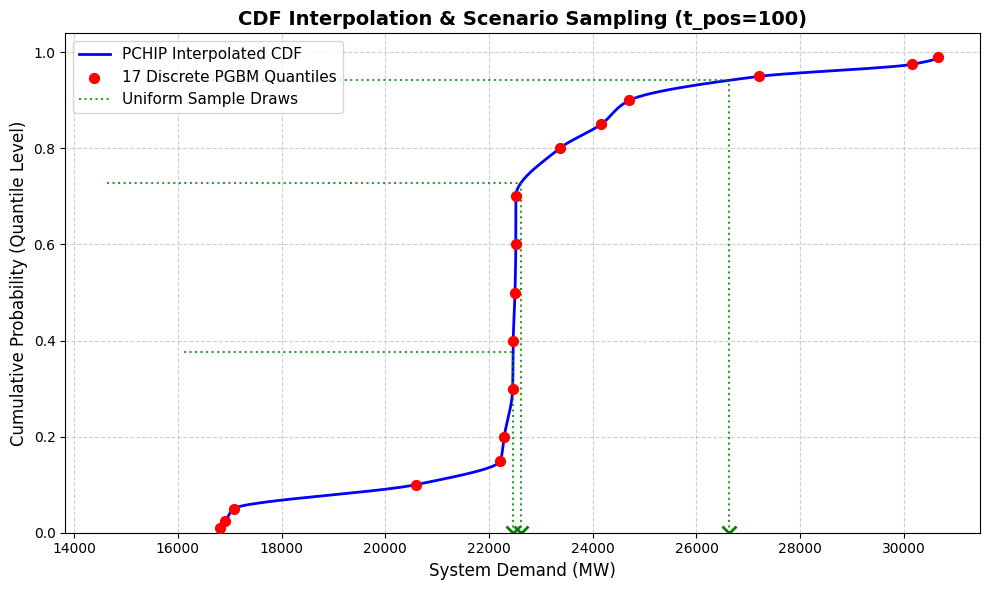

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Define the specific timestep you want to inspect
t_pos = 100

# Extract the data for this timestep (assuming variables are in memory from your script)
q_levels = np.array(QUANTILE_LEVELS)
q_values_mw = pgbm_quantile_preds_mw[t_pos]

# Guard against non-monotonicity (same as your pipeline)
q_values_mw_sorted = np.maximum.accumulate(q_values_mw)

# 1. Build the interpolator
# PchipInterpolator mathematically maps: Probability -> MW
cdf_inverse = PchipInterpolator(q_levels, q_values_mw_sorted, extrapolate=False)

# 2. Generate a dense set of points for the smooth curve
# Create 500 evenly spaced points between your lowest (0.01) and highest (0.99) quantiles
dense_q_levels = np.linspace(q_levels[0], q_levels[-1], 500)
dense_mw_values = cdf_inverse(dense_q_levels)

# 3. Setup the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the smooth interpolated curve (MW on X, Probability on Y)
ax.plot(dense_mw_values, dense_q_levels, color='blue', linewidth=2, 
        label='PCHIP Interpolated CDF')

# Plot the 17 original discrete quantile predictions
ax.scatter(q_values_mw_sorted, q_levels, color='red', zorder=5, s=50,
           label='17 Discrete PGBM Quantiles')

# 4. Illustrate the Inverse Transform Sampling (Monte Carlo Draws)
np.random.seed(42) # For a reproducible visual
n_visual_samples = 3
sample_u = np.random.uniform(q_levels[0], q_levels[-1], n_visual_samples)
sample_mw = cdf_inverse(sample_u)

for i, (u, mw) in enumerate(zip(sample_u, sample_mw)):
    label = 'Uniform Sample Draws' if i == 0 else ""
    # Horizontal line from Y-axis to the curve
    ax.hlines(y=u, xmin=ax.get_xlim()[0], xmax=mw, color='green', linestyle=':', alpha=0.8)
    # Vertical line from the curve to the X-axis
    ax.vlines(x=mw, ymin=0, ymax=u, color='green', linestyle=':', alpha=0.8, label=label)
    # Mark the resulting scenario on the X-axis
    ax.plot(mw, 0, marker='x', color='green', markersize=10, mew=2)

# Styling and labels
ax.set_title(f"CDF Interpolation & Scenario Sampling (t_pos={t_pos})", fontsize=14, fontweight='bold')
ax.set_xlabel("System Demand (MW)", fontsize=12)
ax.set_ylabel("Cumulative Probability (Quantile Level)", fontsize=12)
ax.set_ylim(bottom=0) # Lock bottom to 0 so the drop lines look clean
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

### 2.2.3 Rolling Forecast Loop

In [22]:
# =============================================================================
# build_and_solve_fixed_alpha  — scipy / HiGHS version (no license, no size limit)
# Same LP as the Gurobi version, built with sparse kronecker products.
#
# Variable layout (all concatenated into one vector x):
#   Pg     (N_GEN)            stage-1 dispatch
#   theta1 (N_BUS)            stage-1 voltage angles
#   Pe1    (N_LINE)           stage-1 line flows
#   shed   (N_SCEN * N_BUS)   load shed per scenario-bus
#   curt   (N_SCEN * N_BUS)   curtailment per scenario-bus
#   theta2 (N_SCEN * N_BUS)   stage-2 voltage angles
#   Pe2    (N_SCEN * N_LINE)  stage-2 line flows
# =============================================================================
import numpy as np
from scipy.optimize import linprog
from scipy.sparse import (csr_matrix, eye as speye,
                           kron, vstack as spvstack, hstack as sphstack)

def build_and_solve_fixed_alpha(Pd_hat, node_scen, alpha_fixed,
                                voll=VOLL, c_curt=C_CURT, verbose=False):
    N_SCEN = node_scen.shape[0]
    delta  = node_scen.sum(axis=1) - Pd_hat.sum()   # (N_SCEN,) system imbalance

    # ------------------------------------------------------------------
    # Network incidence matrices (built once, sparse)
    # ------------------------------------------------------------------
    e_idx = np.arange(N_LINE)

    # C_gen[n, g] = 1  if gen_bus_idx[g] == n
    C_gen = csr_matrix(
        (np.ones(N_GEN), (gen_bus_idx, np.arange(N_GEN))),
        shape=(N_BUS, N_GEN))

    # Bf[e, from] = +B[e],  Bf[e, to] = -B[e]   (branch-node, weighted by B)
    Bf = csr_matrix(
        (np.concatenate([ B_line, -B_line]),
         (np.concatenate([e_idx,   e_idx]),
          np.concatenate([from_idx, to_idx]))),
        shape=(N_LINE, N_BUS))

    # A_flow[n, e] = +1 if from_idx[e]==n,  -1 if to_idx[e]==n  (net-outflow)
    A_flow = csr_matrix(
        (np.concatenate([ np.ones(N_LINE), -np.ones(N_LINE)]),
         (np.concatenate([from_idx, to_idx]),
          np.concatenate([e_idx,    e_idx]))),
        shape=(N_BUS, N_LINE))

    B_diag = csr_matrix((B_line, (e_idx, e_idx)), shape=(N_LINE, N_LINE))
    BdBf   = B_diag @ Bf                            # (N_LINE, N_BUS)

    I_S  = speye(N_SCEN,  format='csr')
    I_NL = speye(N_LINE,  format='csr')

    # ------------------------------------------------------------------
    # Variable offsets
    # ------------------------------------------------------------------
    i_Pg,   n_Pg   = 0,           N_GEN
    i_th1,  n_th1  = n_Pg,        N_BUS
    i_Pe1,  n_Pe1  = i_th1+n_th1, N_LINE
    i_shed, n_shed = i_Pe1+n_Pe1, N_SCEN*N_BUS
    i_curt, n_curt = i_shed+n_shed, N_SCEN*N_BUS
    i_th2,  n_th2  = i_curt+n_curt, N_SCEN*N_BUS
    i_Pe2,  n_Pe2  = i_th2+n_th2,  N_SCEN*N_LINE
    N_VAR           = i_Pe2 + n_Pe2

    # ------------------------------------------------------------------
    # Bounds
    # ------------------------------------------------------------------
    lb = np.full(N_VAR, -np.inf)
    ub = np.full(N_VAR,  np.inf)

    # Pg tightened so Pg + alpha*delta stays in [Pg_min, Pg_max] for every scenario.
    # Safety: if wide scenario spread causes lb > ub for a generator, fall back to
    # original [Pg_min, Pg_max] for that generator rather than making the LP infeasible.
    lb_pg = np.maximum(Pg_min, Pg_min - alpha_fixed * delta.min())
    ub_pg = np.minimum(Pg_max, Pg_max - alpha_fixed * delta.max())
    clash = lb_pg > ub_pg
    lb_pg[clash] = Pg_min[clash]
    ub_pg[clash] = Pg_max[clash]
    lb[i_Pg:i_Pg+N_GEN] = lb_pg
    ub[i_Pg:i_Pg+N_GEN] = ub_pg

    lb[i_Pe1:i_Pe1+N_LINE] = -R_line;  ub[i_Pe1:i_Pe1+N_LINE] = R_line

    lb[i_shed:i_shed+n_shed] = 0;      ub[i_shed:i_shed+n_shed] = node_scen.ravel()
    lb[i_curt:i_curt+n_curt] = 0

    lb[i_Pe2:i_Pe2+n_Pe2] = np.tile(-R_line, N_SCEN)
    ub[i_Pe2:i_Pe2+n_Pe2] = np.tile( R_line, N_SCEN)

    # ------------------------------------------------------------------
    # Objective  (constants absorbed into const_offset)
    # ------------------------------------------------------------------
    c_obj = np.zeros(N_VAR)
    c_obj[i_Pg:i_Pg+N_GEN]          = c1
    c_obj[i_shed:i_shed+n_shed]      = voll   / N_SCEN
    c_obj[i_curt:i_curt+n_curt]      = c_curt / N_SCEN
    const_offset = float(np.sum(c0)) + float(np.mean((c1 @ alpha_fixed) * delta))

    # ------------------------------------------------------------------
    # Equality constraints  (6 blocks, stacked vertically)
    # ------------------------------------------------------------------
    Z = csr_matrix   # shorthand

    # [1] theta1[SLACK] == 0   (1 row)
    A1 = Z(([1.0], ([0], [i_th1 + SLACK])), shape=(1, N_VAR))
    b1 = np.array([0.0])

    # [2] Stage-1 DC flow:  Pe1 - BdBf @ theta1 == 0   (N_LINE rows)
    A2 = sphstack([Z((N_LINE, N_GEN)), -BdBf, I_NL,
                   Z((N_LINE, n_shed+n_curt+n_th2+n_Pe2))])
    b2 = np.zeros(N_LINE)

    # [3] Stage-1 balance:  C_gen @ Pg - A_flow @ Pe1 == Pd_hat   (N_BUS rows)
    A3 = sphstack([C_gen, Z((N_BUS, N_BUS)), -A_flow,
                   Z((N_BUS, n_shed+n_curt+n_th2+n_Pe2))])
    b3 = Pd_hat

    # [4] theta2[s, SLACK] == 0 for every s   (N_SCEN rows)
    rows4 = np.arange(N_SCEN)
    cols4 = i_th2 + np.arange(N_SCEN) * N_BUS + SLACK
    A4 = Z((np.ones(N_SCEN), (rows4, cols4)), shape=(N_SCEN, N_VAR))
    b4 = np.zeros(N_SCEN)

    # [5] Stage-2 DC flow:  Pe2[s] - BdBf @ theta2[s] == 0  (N_SCEN*N_LINE rows)
    A5_th2 = kron(I_S, -BdBf)       # (N_SCEN*N_LINE, N_SCEN*N_BUS)
    A5_Pe2 = kron(I_S,  I_NL)       # (N_SCEN*N_LINE, N_SCEN*N_LINE)
    A5 = sphstack([Z((N_SCEN*N_LINE, N_GEN+N_BUS+N_LINE+n_shed+n_curt)),
                   A5_th2, A5_Pe2])
    b5 = np.zeros(N_SCEN * N_LINE)

    # [6] Stage-2 balance  (N_SCEN*N_BUS rows):
    #   C_gen@Pg  +  shed[s,n]  -  curt[s,n]  -  A_flow@Pe2[s]
    #   == node_scen[s,n]  -  (C_gen @ alpha_fixed)[n] * delta[s]
    #
    # Pg appears identically in every scenario block → kron(ones_col, C_gen)
    A6_Pg   = kron(Z(np.ones((N_SCEN, 1))), C_gen)   # (N_SCEN*N_BUS, N_GEN)
    A6_shed =  speye(N_SCEN*N_BUS, format='csr')
    A6_curt = -speye(N_SCEN*N_BUS, format='csr')
    A6_Pe2  = -kron(I_S, A_flow)                      # (N_SCEN*N_BUS, N_SCEN*N_LINE)

    A6 = sphstack([A6_Pg, Z((N_SCEN*N_BUS, N_BUS+N_LINE)),
                   A6_shed, A6_curt, Z((N_SCEN*N_BUS, n_th2)), A6_Pe2])
    alpha_per_bus = C_gen @ alpha_fixed               # (N_BUS,) alpha contribution at each bus
    b6 = node_scen.ravel() - np.outer(delta, alpha_per_bus).ravel()

    A_eq = spvstack([A1, A2, A3, A4, A5, A6], format='csr')
    b_eq = np.concatenate([b1, b2, b3, b4, b5, b6])

    # ------------------------------------------------------------------
    # Solve with HiGHS (built into scipy >= 1.7, free, no size limit)
    # ------------------------------------------------------------------
    result = linprog(c_obj, A_eq=A_eq, b_eq=b_eq,
                     bounds=list(zip(lb, ub)),
                     method='highs',
                     options={'disp': verbose})

    if result.status != 0:
        raise RuntimeError(f"HiGHS status={result.status}: {result.message}")

    x = result.x

    start_idx = 1 + N_LINE
    lmp_1 = result.eqlin.marginals[start_idx : start_idx + N_BUS]

    return {
        "Pg":          x[i_Pg:i_Pg+N_GEN],
        "alpha":       alpha_fixed,
        "delta":       delta,
        "shed":        x[i_shed:i_shed+n_shed].reshape(N_SCEN, N_BUS),
        "curt":        x[i_curt:i_curt+n_curt].reshape(N_SCEN, N_BUS),
        "total_cost":  result.fun + const_offset,
        "stage1_cost": float(c1 @ x[i_Pg:i_Pg+N_GEN] + np.sum(c0)),
        "LMP_1": lmp_1,
    }

# Quick smoke test on the lognormal-scenario forecast (already in memory)
print("Smoke-testing HiGHS solver on Phase-1 scenarios...")
import time; t0 = time.time()
_res = build_and_solve_fixed_alpha(Pd_hat, node_scen, Pg_max / Pg_max.sum(), verbose=False)
print(f"Solved in {time.time()-t0:.1f}s  |  Stage-1 cost: ${_res['stage1_cost']:,.0f}/hr  |  Total: ${_res['total_cost']:,.0f}/hr")
print(f"Sum Pg = {_res['Pg'].sum():.1f} MW,  Sum Pd_hat = {Pd_hat.sum():.1f} MW")


Smoke-testing HiGHS solver on Phase-1 scenarios...
Solved in 3.7s  |  Stage-1 cost: $75,737/hr  |  Total: $87,329/hr
Sum Pg = 3019.1 MW,  Sum Pd_hat = 3019.1 MW


In [ ]:
# =============================================================================
# Rolling evaluation: PGBM → stochastic DC-OPF across many timesteps
# =============================================================================
import numpy as np
import pandas as pd
from tqdm import tqdm

# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------
N_TIMESTEPS_TO_EVAL = 200
N_SCENARIOS_PER_T   = 100
RNG_SEED            = 42

alpha_fixed = Pg_max / Pg_max.sum()
rng = np.random.default_rng(RNG_SEED)

# -----------------------------------------------------------------------------
# Stratified sample of test-set positions
# -----------------------------------------------------------------------------
N_TEST = len(idx_te)
step   = max(1, N_TEST // N_TIMESTEPS_TO_EVAL)
eval_positions = np.arange(0, N_TEST, step)[:N_TIMESTEPS_TO_EVAL]
print(f"Evaluating {len(eval_positions)} timesteps out of {N_TEST} test steps")
print(f"Spacing: {step} steps = {step * 5 / 60:.1f} hours apart")

# -----------------------------------------------------------------------------
# Realized-cost function (same as before — no change)
# -----------------------------------------------------------------------------
def realized_cost(Pg_t, alpha, actual_Pd_nodal, pd_hat_nodal):
    delta_realized = actual_Pd_nodal.sum() - pd_hat_nodal.sum()
    Pg_realized    = Pg_t + alpha * delta_realized
    over  = np.maximum(Pg_realized - Pg_max, 0).sum()
    under = np.maximum(Pg_min - Pg_realized, 0).sum()
    shed  = max(0, actual_Pd_nodal.sum() - min(Pg_realized.sum(), Pg_max.sum()))
    stage1_c   = float(c1 @ Pg_t + np.sum(c0))
    response_c = float(c1 @ alpha) * abs(delta_realized)
    penalty    = VOLL * (over + under + shed)
    return {
        "stage1":     stage1_c,
        "response":   response_c,
        "penalty":    penalty,
        "total":      stage1_c + response_c + penalty,
        "delta":      delta_realized,
        "shed":       shed,
        "limit_viol": over + under,
    }

# -----------------------------------------------------------------------------
# Main loop
# -----------------------------------------------------------------------------
records = []
failed  = []

for t_pos in tqdm(eval_positions, desc="PGBM → stochastic DC-OPF"):
    try:
        Pd_hat_t      = pgbm_forecast_at(t_pos)                              # point forecast
        scenarios_t   = sample_pgbm_scenarios(t_pos, N_SCENARIOS_PER_T, rng) # 100 nodal scenarios
        actual_Pd_t   = pgbm_actual_at(t_pos)                                # realized nodal demand

        res = build_and_solve_fixed_alpha(
            Pd_hat_t, scenarios_t, alpha_fixed, verbose=False
        )
        rlz = realized_cost(res["Pg"], alpha_fixed, actual_Pd_t, Pd_hat_t)

        records.append({
            "t_pos":             int(t_pos),
            "timestamp":         idx_te[t_pos],
            "hour":              idx_te[t_pos].hour,
            "dow":               idx_te[t_pos].dayofweek,
            # PGBM forecast info
            "pgbm_median_mw":    float(Pd_hat_t.sum()),
            "pgbm_scen_mean":    float(scenarios_t.sum(axis=1).mean()),
            "pgbm_scen_std":     float(scenarios_t.sum(axis=1).std()),
            "actual_mw":         float(actual_Pd_t.sum()),
            "forecast_error":    float(Pd_hat_t.sum() - actual_Pd_t.sum()),
            # Stochastic program outputs
            "sp_expected_cost":  res["total_cost"],
            "sp_stage1_cost":    res["stage1_cost"],
            "Pg_total":          float(res["Pg"].sum()),
            # Realized performance
            "realized_total":    rlz["total"],
            "realized_delta":    rlz["delta"],
            "realized_shed":     rlz["shed"],
            "limit_viol_mw":     rlz["limit_viol"],
        })
    except Exception as e:
        failed.append((int(t_pos), str(e)))

print(f"\nSolved: {len(records)}/{len(eval_positions)}   Failed: {len(failed)}")
if failed:
    print("First 3 failures:", failed[:3])

# -----------------------------------------------------------------------------
# Aggregate + report
# -----------------------------------------------------------------------------
results_pgbm = pd.DataFrame(records)

print("\n" + "=" * 60)
print("PGBM → stochastic DC-OPF evaluation summary")
print("=" * 60)

print("\nForecast quality:")
print(f"  MAE:                     {results_pgbm['forecast_error'].abs().mean():>10,.1f} MW")
print(f"  Bias:                    {results_pgbm['forecast_error'].mean():>10,.1f} MW")
print(f"  Avg scenario std:        {results_pgbm['pgbm_scen_std'].mean():>10,.1f} MW")

print("\nCost outputs:")
print(f"  E[SP expected cost]:     ${results_pgbm['sp_expected_cost'].mean():>12,.2f}/hr")
print(f"  E[realized cost]:        ${results_pgbm['realized_total'].mean():>12,.2f}/hr")
gap = (results_pgbm['realized_total'] - results_pgbm['sp_expected_cost']).mean()
print(f"  Calibration gap:         ${gap:>12,.2f}/hr  (positive ⇒ SP underestimates)")

print("\nRealized performance:")
print(f"  Avg Pg committed:        {results_pgbm['Pg_total'].mean():>10,.1f} MW")
print(f"  Avg actual demand:       {results_pgbm['actual_mw'].mean():>10,.1f} MW")
print(f"  Avg load shed:           {results_pgbm['realized_shed'].mean():>10,.2f} MW")
print(f"  Avg limit violation:     {results_pgbm['limit_viol_mw'].mean():>10,.2f} MW")

print("\nBy hour of day:")
hourly = results_pgbm.groupby("hour").agg({
    "forecast_error":  lambda x: x.abs().mean(),
    "realized_total":  "mean",
    "realized_shed":   "mean",
}).round(2)
hourly.columns = ["forecast_MAE", "realized_cost", "avg_shed"]
print(hourly.to_string())

# -----------------------------------------------------------------------------
# Diagnostic plots
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(results_pgbm["pgbm_median_mw"], results_pgbm["actual_mw"], s=10, alpha=0.6)
lo, hi = results_pgbm["actual_mw"].min(), results_pgbm["actual_mw"].max()
axes[0, 0].plot([lo, hi], [lo, hi], 'r--', label="perfect forecast")
axes[0, 0].set_xlabel("PGBM median forecast (MW)")
axes[0, 0].set_ylabel("Actual demand (MW)")
axes[0, 0].set_title("PGBM forecast quality")
axes[0, 0].legend()

axes[0, 1].hist(results_pgbm["forecast_error"], bins=40, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel("Forecast error (MW)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Forecast error distribution")

axes[1, 0].scatter(results_pgbm["forecast_error"].abs(), results_pgbm["realized_total"],
                   s=10, alpha=0.6)
axes[1, 0].set_xlabel("|Forecast error| (MW)")
axes[1, 0].set_ylabel("Realized cost ($/hr)")
axes[1, 0].set_title("Realized cost vs. forecast error")

axes[1, 1].plot(results_pgbm["timestamp"], results_pgbm["sp_expected_cost"],
                'o-', markersize=3, alpha=0.5, label="SP expected")
axes[1, 1].plot(results_pgbm["timestamp"], results_pgbm["realized_total"],
                'o-', markersize=3, alpha=0.5, label="realized")
axes[1, 1].set_xlabel("Timestamp")
axes[1, 1].set_ylabel("Cost ($/hr)")
axes[1, 1].set_title("Expected vs. realized over time")
axes[1, 1].legend()
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

Evaluating 200 timesteps out of 21013 test steps
Spacing: 105 steps = 8.8 hours apart


PGBM → stochastic DC-OPF:  44%|████▎     | 87/200 [04:36<08:05,  4.30s/it]

In [ ]:
# =============================================================================
# Diagnostics — run this WITHOUT re-running the 40-minute loop above
# =============================================================================
print(f"Successful records: {len(records)}")
print(f"Failed solves:      {len(failed)}")

if failed:
    print("\nFirst 5 failure messages:")
    for t, msg in failed[:5]:
        print(f"  t_pos={t}: {msg}")

if records:
    # Rebuild the DataFrame and run the full report
    results_pgbm = pd.DataFrame(records)
    print(f"\nColumns: {list(results_pgbm.columns)}")
    print(results_pgbm.head(3))
else:
    print("\nNo successful records — see failure messages above to fix the solver issue.")
    print("Common causes:")
    print("  1. build_and_solve_fixed_alpha not defined (run cell 35 first)")
    print("  2. Gurobi license issue (check gp.Model() in a fresh cell)")
    print("  3. Infeasible LP — check if Pg_max constraints conflict with large delta_s")


Successful records: 152
Failed solves:      48

First 5 failure messages:
  t_pos=210: HiGHS status=2: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
  t_pos=525: HiGHS status=2: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
  t_pos=1050: HiGHS status=2: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
  t_pos=1365: HiGHS status=2: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
  t_pos=1680: HiGHS status=2: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)

Columns: ['t_pos', 'timestamp', 'hour', 'dow', 'pgbm_median_mw', 'pgbm_scen_mean', 'pgbm_scen_std', 'actual_mw', 'forecast_error', 'sp_expected_cost', 'sp_stage1_cost', 'Pg_total', 'realized_total', 'realized_delta', 'realized_shed', 'limit_viol_mw']
   t_pos           timestamp  hour  dow  pgbm_media


PGBM → stochastic DC-OPF evaluation summary

Forecast quality:
  MAE:                          227.8 MW
  Bias:                         -37.0 MW
  Avg scenario std:             351.7 MW

Cost outputs:
  E[SP expected cost]:     $  109,835.60/hr
  E[realized cost]:        $  101,664.46/hr
  Calibration gap:         $   -8,171.14/hr  (positive => SP underestimates)

Realized performance:
  Avg Pg committed:           3,816.6 MW
  Avg actual demand:          3,853.6 MW
  Avg load shed:                 0.00 MW
  Avg limit violation:           0.28 MW

By hour of day:
      forecast_MAE  realized_cost  avg_shed
hour                                       
0            46.44      129624.04       0.0
1            37.48       82794.74       0.0
2            76.05       84873.19       0.0
3            98.89       80749.87       0.0
4           182.23       88257.17       0.0
5           150.50       88857.45       0.0
6           376.89       99512.21       0.0
7           362.95      107675.93

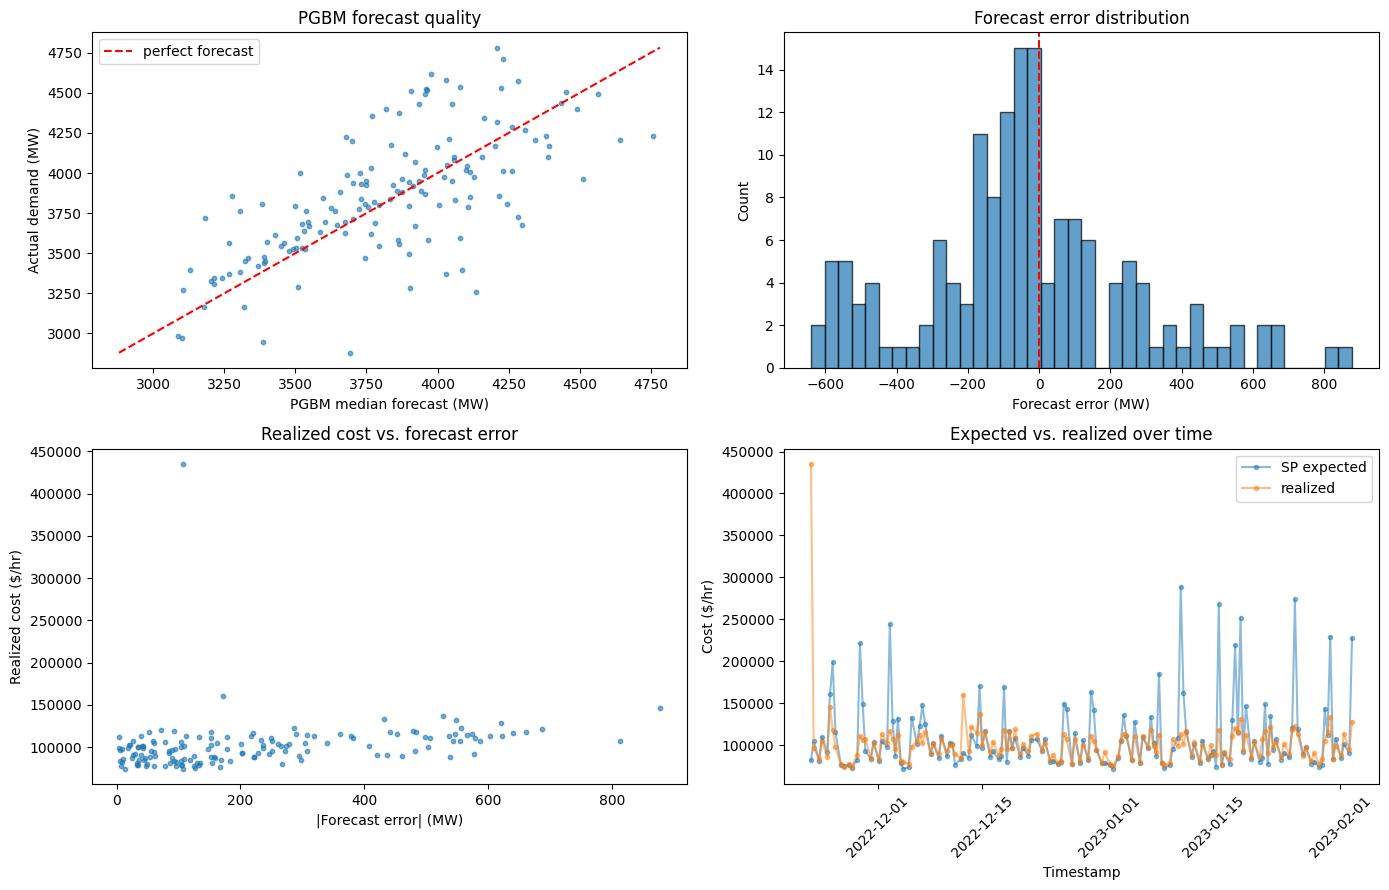

In [ ]:
# =============================================================================
# Reporting + plots — run this after the diagnostic cell confirms records is populated
# =============================================================================
import matplotlib.pyplot as plt

assert len(records) > 0, "No successful records to report. Run diagnostics cell first."
results_pgbm = pd.DataFrame(records)

print("\n" + "=" * 60)
print("PGBM → stochastic DC-OPF evaluation summary")
print("=" * 60)

print("\nForecast quality:")
print(f"  MAE:                     {results_pgbm['forecast_error'].abs().mean():>10,.1f} MW")
print(f"  Bias:                    {results_pgbm['forecast_error'].mean():>10,.1f} MW")
print(f"  Avg scenario std:        {results_pgbm['pgbm_scen_std'].mean():>10,.1f} MW")

print("\nCost outputs:")
print(f"  E[SP expected cost]:     ${results_pgbm['sp_expected_cost'].mean():>12,.2f}/hr")
print(f"  E[realized cost]:        ${results_pgbm['realized_total'].mean():>12,.2f}/hr")
gap = (results_pgbm['realized_total'] - results_pgbm['sp_expected_cost']).mean()
print(f"  Calibration gap:         ${gap:>12,.2f}/hr  (positive => SP underestimates)")

print("\nRealized performance:")
print(f"  Avg Pg committed:        {results_pgbm['Pg_total'].mean():>10,.1f} MW")
print(f"  Avg actual demand:       {results_pgbm['actual_mw'].mean():>10,.1f} MW")
print(f"  Avg load shed:           {results_pgbm['realized_shed'].mean():>10,.2f} MW")
print(f"  Avg limit violation:     {results_pgbm['limit_viol_mw'].mean():>10,.2f} MW")

print("\nBy hour of day:")
hourly = results_pgbm.groupby("hour").agg({
    "forecast_error":  lambda x: x.abs().mean(),
    "realized_total":  "mean",
    "realized_shed":   "mean",
}).round(2)
hourly.columns = ["forecast_MAE", "realized_cost", "avg_shed"]
print(hourly.to_string())

# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(results_pgbm["pgbm_median_mw"], results_pgbm["actual_mw"], s=10, alpha=0.6)
lo, hi = results_pgbm["actual_mw"].min(), results_pgbm["actual_mw"].max()
axes[0, 0].plot([lo, hi], [lo, hi], 'r--', label="perfect forecast")
axes[0, 0].set_xlabel("PGBM median forecast (MW)")
axes[0, 0].set_ylabel("Actual demand (MW)")
axes[0, 0].set_title("PGBM forecast quality")
axes[0, 0].legend()

axes[0, 1].hist(results_pgbm["forecast_error"], bins=40, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel("Forecast error (MW)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Forecast error distribution")

axes[1, 0].scatter(results_pgbm["forecast_error"].abs(), results_pgbm["realized_total"],
                   s=10, alpha=0.6)
axes[1, 0].set_xlabel("|Forecast error| (MW)")
axes[1, 0].set_ylabel("Realized cost ($/hr)")
axes[1, 0].set_title("Realized cost vs. forecast error")

axes[1, 1].plot(results_pgbm["timestamp"], results_pgbm["sp_expected_cost"],
                'o-', markersize=3, alpha=0.5, label="SP expected")
axes[1, 1].plot(results_pgbm["timestamp"], results_pgbm["realized_total"],
                'o-', markersize=3, alpha=0.5, label="realized")
axes[1, 1].set_xlabel("Timestamp")
axes[1, 1].set_ylabel("Cost ($/hr)")
axes[1, 1].set_title("Expected vs. realized over time")
axes[1, 1].legend()
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [ ]:

# =============================================================================
# Demand comparison: PGBM forecast vs. actual over evaluation period
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

df = results_pgbm.sort_values("timestamp").reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [3, 1]})

# --- top panel: time-series with uncertainty band ---
ax = axes[0]
ax.fill_between(
    df["timestamp"],
    df["pgbm_scen_mean"] - df["pgbm_scen_std"],
    df["pgbm_scen_mean"] + df["pgbm_scen_std"],
    alpha=0.25, color="steelblue", label="±1σ scenario spread"
)
ax.plot(df["timestamp"], df["pgbm_median_mw"],
        color="steelblue", linewidth=1.5, label="PGBM median forecast")
ax.plot(df["timestamp"], df["actual_mw"],
        color="darkorange", linewidth=1.5, linestyle="--", label="Actual demand")
ax.plot(df["timestamp"], df["Pg_total"],
        color="green", linewidth=1.2, linestyle=":", label="Committed Pg (stage-1)")
ax.set_ylabel("System load (MW)")
ax.set_title("PGBM forecast vs. actual demand — evaluation period")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.grid(True, alpha=0.3)

# --- bottom panel: signed forecast error ---
ax2 = axes[1]
ax2.bar(df["timestamp"], df["forecast_error"],
        width=0.003, color=np.where(df["forecast_error"] >= 0, "steelblue", "salmon"),
        alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Forecast error (MW)")
ax2.set_xlabel("Timestamp")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- scatter: forecast vs. actual coloured by hour of day ---
fig2, ax3 = plt.subplots(figsize=(8, 7))
sc = ax3.scatter(
    df["pgbm_median_mw"], df["actual_mw"],
    c=df["hour"], cmap="twilight", s=20, alpha=0.8
)
lo = min(df["pgbm_median_mw"].min(), df["actual_mw"].min()) * 0.98
hi = max(df["pgbm_median_mw"].max(), df["actual_mw"].max()) * 1.02
mae = df["forecast_error"].abs().mean()
ax3.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="perfect forecast")
ax3.fill_between([lo, hi],
                 [lo - mae, hi - mae],
                 [lo + mae, hi + mae],
                 alpha=0.1, color="red", label=f"±MAE ({mae:.0f} MW)")
cbar = plt.colorbar(sc, ax=ax3)
cbar.set_label("Hour of day")
ax3.set_xlabel("PGBM median forecast (MW)")
ax3.set_ylabel("Actual demand (MW)")
ax3.set_title("Forecast vs. actual — coloured by hour of day")
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Phase 3: Smart Predict Then Optimize
references: elmachtoub SPTO

### 3.2 Train Simple Neural Net Using SPO Loss

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm

# 1. Simple Feed-Forward Network
class SPONet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Predicts system load in stationary space
        )
    def forward(self, x):
        return self.net(x).squeeze()

# 2. The SPO+ Training Loop
def train_spo_net(X_tr, y_tr_resid, trend_season_mw, load_scaler, nodal_base, median_load, node_scen_tr, epochs=5):
    """
    X_tr: Features (N, p)
    y_tr_resid: True load in stationary space (N,)
    trend_season_mw: The mw_offset_per_t for the training set (N,)
    node_scen_tr: Scenario dataset to run the LP during training (N, N_SCEN, N_BUS)
    """
    net = SPONet(X_tr.shape[1])
    optimizer = optim.Adam(net.parameters(), lr=1e-3)
    
    # Pre-convert static scaling factors to tensors
    X_tensor = torch.tensor(X_tr, dtype=torch.float32)
    scaler_mean = torch.tensor(load_scaler.mean_[0], dtype=torch.float32)
    scaler_scale = torch.tensor(load_scaler.scale_[0], dtype=torch.float32)
    nodal_scale_factor = torch.tensor(nodal_base / median_load, dtype=torch.float32)

    net.train()
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        
        # Standard SGD (Batch size = 1 is standard for SPO+ to evaluate the LP oracle)
        for i in tqdm(range(len(X_tensor))):
            x_i = X_tensor[i]
            
            # --- FORWARD PASS (Predict Nodal Demand) ---
            pred_stat = net(x_i)
            # Unscale from stationary space -> CAISO MW -> Nodal IEEE MW
            pred_caiso_mw = (pred_stat * scaler_scale) + scaler_mean + trend_season_mw[i]
            Pd_hat = pred_caiso_mw * nodal_scale_factor
            
            # True Nodal Demand
            true_caiso_mw = (y_tr_resid[i] * load_scaler.scale_[0]) + load_scaler.mean_[0] + trend_season_mw[i]
            Pd_true = true_caiso_mw * nodal_scale_factor
            
            # --- OPTIMIZATION ORACLE (Detached from autograd) ---
            with torch.no_grad():
                Pd_hat_np = Pd_hat.numpy()
                Pd_true_np = Pd_true.numpy()
                scenarios_np = node_scen_tr[i] # Provide scenario context for the LP
                
                # Oracle at c (True Demand)
                res_true = build_and_solve_fixed_alpha(Pd_true_np, scenarios_np, alpha_fixed)
                w_true = res_true["LMP_1"]
                
                # Oracle at 2c_hat - c (SPO+ requirement)
                Pd_spo_np = 2 * Pd_hat_np - Pd_true_np
                res_spo = build_and_solve_fixed_alpha(Pd_spo_np, scenarios_np, alpha_fixed)
                w_spo = res_spo["LMP_1"]
                
                # Compute SPO+ Subgradient w.r.t the nodal predictions
                # g = 2 * (w*(c) - w*(2c_hat - c))
                g = 2 * (w_true - w_spo)
                g_tensor = torch.tensor(g, dtype=torch.float32)

            # --- BACKPROPAGATION ---
            optimizer.zero_grad()
            
            # The Surrogate Loss Trick: 
            # Differentiating (Pd_hat * g_tensor) w.r.t Pd_hat yields exactly g_tensor.
            # This seamlessly pushes the LP subgradient back through the affine scaling and the NN.
            loss_surrogate = torch.sum(Pd_hat * g_tensor)
            loss_surrogate.backward()
            
            optimizer.step()
            
    return net

# Run it!
print("Training SPO+ Neural Network...")
# Note: You will need to construct `node_scen_tr`, which is just a set of scenarios 
# for the training set. If stochastic training is too slow, you can use a single 
# deterministic scenario (actual realized) to speed up the epoch times drastically.
spo_model = train_spo_net(X_tr, y_tr, mw_offset_per_t_train, load_scaler, NODAL_BASE_MW, MEDIAN_LOAD_TRAIN, training_scenarios)

ModuleNotFoundError: No module named 'torch'

### 3.3 Rerun PtO pipeline

In [ ]:
# =============================================================================
# Phase 3: Neural Net (MSE) + KNN Conditional Residual Bootstrap Scenarios
# =============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler as FeatScaler
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────────────
# 1. Train neural net with MSE loss (point predictor in stationary space)
# ─────────────────────────────────────────────────────────────────────────────
HIDDEN = 64
LR     = 1e-3
EPOCHS = 50
BATCH  = 256

# Standardize features independently of load_scaler
feat_scaler = FeatScaler().fit(X_tr)
X_tr_sc     = feat_scaler.transform(X_tr)
X_te_sc     = feat_scaler.transform(X_te)

X_t = torch.tensor(X_tr_sc, dtype=torch.float32)
y_t = torch.tensor(y_tr,    dtype=torch.float32)

net = nn.Sequential(
    nn.Linear(X_tr.shape[1], HIDDEN), nn.ReLU(),
    nn.Linear(HIDDEN, HIDDEN),        nn.ReLU(),
    nn.Linear(HIDDEN, 1),
)
opt     = optim.Adam(net.parameters(), lr=LR)
loss_fn = nn.MSELoss()

loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_t, y_t),
    batch_size=BATCH, shuffle=True
)

net.train()
for epoch in range(EPOCHS):
    ep_loss = 0.0
    for xb, yb in loader:
        opt.zero_grad()
        l = loss_fn(net(xb).squeeze(), yb)
        l.backward()
        opt.step()
        ep_loss += l.item() * len(xb)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train MSE={ep_loss/len(X_t):.5f}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Training residuals in stationary space
# ─────────────────────────────────────────────────────────────────────────────
net.eval()
with torch.no_grad():
    pred_tr_stat = net(X_t).squeeze().numpy()

train_residuals = y_tr - pred_tr_stat   # shape (N_train,)

print(f"\nTraining residuals — mean: {train_residuals.mean():.4f}  "
      f"std: {train_residuals.std():.4f}  "
      f"p5: {np.percentile(train_residuals,  5):.4f}  "
      f"p95: {np.percentile(train_residuals, 95):.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. KNN index on standardized training features
#    K_NEIGHBORS controls residual pool size. Larger K = smoother/more global.
# ─────────────────────────────────────────────────────────────────────────────
K_NEIGHBORS = 50

knn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="euclidean", n_jobs=-1)
knn.fit(X_tr_sc)
print(f"\nKNN index built  (K={K_NEIGHBORS}, N_train={len(X_tr_sc):,})")

# ─────────────────────────────────────────────────────────────────────────────
# 4. Trend + seasonal offset for test set
#    Identical formula to mw_offset_per_t in the PGBM scenario cell.
# ─────────────────────────────────────────────────────────────────────────────
mw_offset_nn = (
    load_trend_5m_te.reindex(idx_te).values
    + sum(s.reindex(idx_te).values for s in load_seasons_5m_te.values())
)

# ─────────────────────────────────────────────────────────────────────────────
# 5. Helper functions (mirror pgbm_forecast_at / sample_pgbm_scenarios)
# ─────────────────────────────────────────────────────────────────────────────
def nn_forecast_at(t_pos):
    """Point forecast: stationary -> CAISO MW -> nodal IEEE-118 MW."""
    x = torch.tensor(X_te_sc[t_pos : t_pos + 1], dtype=torch.float32)
    with torch.no_grad():
        pred_stat = net(x).item()
    pred_mw = pred_stat * load_scaler.scale_[0] + load_scaler.mean_[0] + mw_offset_nn[t_pos]
    return pred_mw * (NODAL_BASE_MW / MEDIAN_LOAD_TRAIN)   # (N_BUS,)


def sample_nn_knn_scenarios(t_pos, n_scenarios=100, rng=None):
    """
    KNN conditional residual bootstrap:
      1. Find K nearest training neighbours in feature space.
      2. Draw n_scenarios residuals (with replacement) from their error pool.
      3. Add to point prediction and reconstruct to nodal MW.
    """
    if rng is None:
        rng = np.random.default_rng()

    # KNN lookup
    _, nbr_idx = knn.kneighbors(X_te_sc[t_pos : t_pos + 1])  # (1, K)
    resid_pool = train_residuals[nbr_idx[0]]                   # (K,)
    sampled    = rng.choice(resid_pool, size=n_scenarios, replace=True)

    # Reconstruct to CAISO MW
    x = torch.tensor(X_te_sc[t_pos : t_pos + 1], dtype=torch.float32)
    with torch.no_grad():
        pred_stat = net(x).item()
    scen_stat = pred_stat + sampled                            # (N_SCEN,)
    scen_mw   = scen_stat * load_scaler.scale_[0] + load_scaler.mean_[0] + mw_offset_nn[t_pos]

    # Convert to nodal
    return np.outer(scen_mw, NODAL_BASE_MW / MEDIAN_LOAD_TRAIN)  # (N_SCEN, N_BUS)


def nn_actual_at(t_pos):
    """Realized nodal demand (same reconstruction path as PGBM)."""
    actual_mw = (
        y_te[t_pos] * load_scaler.scale_[0]
        + load_scaler.mean_[0]
        + mw_offset_nn[t_pos]
    )
    return actual_mw * (NODAL_BASE_MW / MEDIAN_LOAD_TRAIN)

# ─────────────────────────────────────────────────────────────────────────────
# 6. Rolling evaluation — same eval_positions / alpha_fixed as Phase 2
# ─────────────────────────────────────────────────────────────────────────────
rng_nn     = np.random.default_rng(RNG_SEED)
records_nn = []
failed_nn  = []

for t_pos in tqdm(eval_positions, desc="NN+KNN -> stochastic DC-OPF"):
    try:
        Pd_hat_t    = nn_forecast_at(t_pos)
        scenarios_t = sample_nn_knn_scenarios(t_pos, N_SCENARIOS_PER_T, rng_nn)
        actual_Pd_t = nn_actual_at(t_pos)

        res = build_and_solve_fixed_alpha(
            Pd_hat_t, scenarios_t, alpha_fixed, verbose=False
        )
        rlz = realized_cost(res["Pg"], alpha_fixed, actual_Pd_t, Pd_hat_t)

        records_nn.append({
            "t_pos":            int(t_pos),
            "timestamp":        idx_te[t_pos],
            "hour":             idx_te[t_pos].hour,
            "dow":              idx_te[t_pos].dayofweek,
            "nn_median_mw":     float(Pd_hat_t.sum()),
            "nn_scen_mean":     float(scenarios_t.sum(axis=1).mean()),
            "nn_scen_std":      float(scenarios_t.sum(axis=1).std()),
            "actual_mw":        float(actual_Pd_t.sum()),
            "forecast_error":   float(Pd_hat_t.sum() - actual_Pd_t.sum()),
            "sp_expected_cost": res["total_cost"],
            "sp_stage1_cost":   res["stage1_cost"],
            "Pg_total":         float(res["Pg"].sum()),
            "realized_total":   rlz["total"],
            "realized_delta":   rlz["delta"],
            "realized_shed":    rlz["shed"],
            "limit_viol_mw":    rlz["limit_viol"],
        })
    except Exception as e:
        failed_nn.append((int(t_pos), str(e)))

print(f"\nSolved: {len(records_nn)}/{len(eval_positions)}   Failed: {len(failed_nn)}")
if failed_nn:
    print("First 3 failures:", failed_nn[:3])

results_nn = pd.DataFrame(records_nn)

print("\n" + "=" * 60)
print("NN + KNN Residual Bootstrap -> stochastic DC-OPF summary")
print("=" * 60)
print(f"  MAE:                     {results_nn['forecast_error'].abs().mean():>10,.1f} MW")
print(f"  Bias:                    {results_nn['forecast_error'].mean():>10,.1f} MW")
print(f"  Avg scenario std:        {results_nn['nn_scen_std'].mean():>10,.1f} MW")
print(f"  E[SP expected cost]:     ${results_nn['sp_expected_cost'].mean():>12,.2f}/hr")
print(f"  E[realized cost]:        ${results_nn['realized_total'].mean():>12,.2f}/hr")
gap_nn = (results_nn['realized_total'] - results_nn['sp_expected_cost']).mean()
print(f"  Calibration gap:         ${gap_nn:>12,.2f}/hr")
print(f"  Avg load shed:           {results_nn['realized_shed'].mean():>10,.2f} MW")
print(f"  Avg limit violation:     {results_nn['limit_viol_mw'].mean():>10,.2f} MW")


### 3.4 Compare Results

In [ ]:
# =============================================================================
# Phase 2 vs Phase 3: Head-to-head comparison
# Requires: results_pgbm (cell 37) and results_nn (cell 45) both in memory
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Align on shared timesteps
shared = pd.merge(
    results_pgbm[["t_pos","timestamp","hour",
                   "pgbm_median_mw","pgbm_scen_std","actual_mw",
                   "forecast_error","sp_expected_cost","realized_total",
                   "realized_shed","limit_viol_mw","Pg_total"]].rename(columns={
        "pgbm_median_mw": "pgbm_mw", "pgbm_scen_std": "pgbm_std",
        "forecast_error": "pgbm_err", "sp_expected_cost": "pgbm_sp_cost",
        "realized_total": "pgbm_realized", "realized_shed": "pgbm_shed",
        "limit_viol_mw": "pgbm_viol", "Pg_total": "pgbm_Pg"}),
    results_nn[["t_pos","nn_median_mw","nn_scen_std",
                 "forecast_error","sp_expected_cost","realized_total",
                 "realized_shed","limit_viol_mw","Pg_total"]].rename(columns={
        "nn_median_mw": "nn_mw", "nn_scen_std": "nn_std",
        "forecast_error": "nn_err", "sp_expected_cost": "nn_sp_cost",
        "realized_total": "nn_realized", "realized_shed": "nn_shed",
        "limit_viol_mw": "nn_viol", "Pg_total": "nn_Pg"}),
    on="t_pos"
)
print(f"Shared timesteps for comparison: {len(shared)}")

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
metrics = {
    "Forecast MAE (MW)":       (shared["pgbm_err"].abs().mean(),    shared["nn_err"].abs().mean()),
    "Forecast bias (MW)":      (shared["pgbm_err"].mean(),          shared["nn_err"].mean()),
    "Avg scen std (MW)":       (shared["pgbm_std"].mean(),          shared["nn_std"].mean()),
    "E[SP cost] ($/hr)":       (shared["pgbm_sp_cost"].mean(),      shared["nn_sp_cost"].mean()),
    "E[realized cost] ($/hr)": (shared["pgbm_realized"].mean(),     shared["nn_realized"].mean()),
    "Calibration gap ($/hr)":  (
        (shared["pgbm_realized"] - shared["pgbm_sp_cost"]).mean(),
        (shared["nn_realized"]   - shared["nn_sp_cost"]).mean(),
    ),
    "Avg load shed (MW)":      (shared["pgbm_shed"].mean(),         shared["nn_shed"].mean()),
    "Avg limit viol (MW)":     (shared["pgbm_viol"].mean(),         shared["nn_viol"].mean()),
}

print("\n" + "=" * 65)
print(f"  {'Metric':<30} {'PGBM (Ph.2)':>14} {'NN+KNN (Ph.3)':>14}")
print("=" * 65)
for name, (v_pgbm, v_nn) in metrics.items():
    winner = "<<" if v_nn < v_pgbm else "  "
    print(f"  {name:<30} {v_pgbm:>14,.2f} {v_nn:>14,.2f}  {winner}")
print("=" * 65)
print("  << = lower is better")

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Realized cost over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(shared["timestamp"], shared["pgbm_realized"], "o-",
         markersize=3, alpha=0.7, color="steelblue", label="PGBM (Ph.2)")
ax1.plot(shared["timestamp"], shared["nn_realized"], "s-",
         markersize=3, alpha=0.7, color="darkorange", label="NN+KNN (Ph.3)")
ax1.set_ylabel("Realized cost ($/hr)")
ax1.set_title("Realized operating cost over evaluation period")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Cost distribution
ax2 = fig.add_subplot(gs[1, 0])
bins = np.linspace(
    min(shared["pgbm_realized"].min(), shared["nn_realized"].min()),
    max(shared["pgbm_realized"].max(), shared["nn_realized"].max()),
    40
)
ax2.hist(shared["pgbm_realized"], bins=bins, alpha=0.6, color="steelblue",
         label="PGBM",   edgecolor="white")
ax2.hist(shared["nn_realized"],   bins=bins, alpha=0.6, color="darkorange",
         label="NN+KNN", edgecolor="white")
ax2.axvline(shared["pgbm_realized"].mean(), color="steelblue",  linestyle="--", linewidth=1.5)
ax2.axvline(shared["nn_realized"].mean(),   color="darkorange", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Realized cost ($/hr)")
ax2.set_ylabel("Count")
ax2.set_title("Realized cost distribution")
ax2.legend()

# 3. Forecast error distribution
ax3 = fig.add_subplot(gs[1, 1])
bins_e = np.linspace(
    min(shared["pgbm_err"].min(), shared["nn_err"].min()),
    max(shared["pgbm_err"].max(), shared["nn_err"].max()),
    40
)
ax3.hist(shared["pgbm_err"], bins=bins_e, alpha=0.6, color="steelblue",
         label="PGBM",   edgecolor="white")
ax3.hist(shared["nn_err"],   bins=bins_e, alpha=0.6, color="darkorange",
         label="NN+KNN", edgecolor="white")
ax3.axvline(0, color="black", linewidth=0.8)
ax3.set_xlabel("Forecast error (MW)")
ax3.set_ylabel("Count")
ax3.set_title("Forecast error distribution")
ax3.legend()

# 4. Scenario spread vs. actual demand
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(shared["actual_mw"], shared["pgbm_std"], s=15, alpha=0.6,
            color="steelblue",  label="PGBM std")
ax4.scatter(shared["actual_mw"], shared["nn_std"],   s=15, alpha=0.6,
            color="darkorange", label="NN+KNN std")
ax4.set_xlabel("Actual system demand (MW)")
ax4.set_ylabel("Scenario std dev (MW)")
ax4.set_title("Scenario spread vs. demand level")
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Realized cost vs. |forecast error|
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(shared["pgbm_err"].abs(), shared["pgbm_realized"], s=15,
            alpha=0.6, color="steelblue",  label="PGBM")
ax5.scatter(shared["nn_err"].abs(),   shared["nn_realized"],   s=15,
            alpha=0.6, color="darkorange", label="NN+KNN")
ax5.set_xlabel("|Forecast error| (MW)")
ax5.set_ylabel("Realized cost ($/hr)")
ax5.set_title("Cost sensitivity to forecast error")
ax5.legend()
ax5.grid(True, alpha=0.3)

fig.suptitle("Phase 2 (PGBM) vs. Phase 3 (NN + KNN Bootstrap): head-to-head",
             fontsize=13, fontweight="bold")
plt.show()
